# AI & DL: SpamBase Seminar Project

Binary classification on the [Spambase dataset](https://archive.ics.uci.edu/dataset/94/spambase) from the UCI Machine Learning Repository.  
The goal is to classify emails as **spam (1)** or **non-spam (0)** using various ML methods and compare their performance.

## Import Packages

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, RocCurveDisplay
)
from xgboost import XGBClassifier

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

## Data Loading

In [4]:
# UCI order (57 features + label); used when the Kaggle file has no header (e.g. spambase.data).
_SPAMBASE_COLS = [
    'word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d', 'word_freq_our',
    'word_freq_over', 'word_freq_remove', 'word_freq_internet', 'word_freq_order', 'word_freq_mail',
    'word_freq_receive', 'word_freq_will', 'word_freq_people', 'word_freq_report', 'word_freq_addresses',
    'word_freq_free', 'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit',
    'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money', 'word_freq_hp',
    'word_freq_hpl', 'word_freq_george', 'word_freq_650', 'word_freq_lab', 'word_freq_labs',
    'word_freq_telnet', 'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85',
    'word_freq_technology', 'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct',
    'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project', 'word_freq_re',
    'word_freq_edu', 'word_freq_table', 'word_freq_conference',
    'char_freq_;', 'char_freq_(', 'char_freq_[', 'char_freq_!', 'char_freq_$', 'char_freq_#',
    'capital_run_length_average', 'capital_run_length_longest', 'capital_run_length_total', 'spam',
]

try:
    spambase = fetch_ucirepo(id=94)
    X = spambase.data.features
    y = spambase.data.targets
    df = pd.concat([X, y], axis=1)
except Exception as e:
    print(f"UCI ML Repo unavailable ({type(e).__name__}: {e}). Loading Spambase from Kaggle (colormap/spambase) …")
    # Optional: pip install "kagglehub[pandas-datasets]" and Kaggle API credentials if needed.
    import kagglehub
    from pathlib import Path

    df = None
    _pandas_loader = getattr(kagglehub, 'load_dataset', None) or getattr(kagglehub, 'dataset_load', None)
    try:
        from kagglehub import KaggleDatasetAdapter
        if _pandas_loader is not None:
            for _fp in ('spambase.csv', 'spambase.data'):
                try:
                    df = _pandas_loader(
                        KaggleDatasetAdapter.PANDAS,
                        'colormap/spambase',
                        _fp,
                    )
                    if df is not None and len(df) > 0:
                        break
                except Exception:
                    df = None
                    continue
    except ImportError:
        pass

    if df is None:
        root = Path(kagglehub.dataset_download('colormap/spambase'))
        paths = []
        for name in ('spambase.data', 'spambase.csv', 'Spambase.csv'):
            paths.extend(sorted(root.rglob(name)))
        if not paths:
            raise FileNotFoundError(f'No spambase.data / *.csv under {root}') from e
        path = paths[0]
        peek = pd.read_csv(path, header=None, nrows=2)
        first = peek.iloc[0, 0]
        try:
            float(first)
            has_header = False
        except (TypeError, ValueError):
            has_header = True
        if has_header:
            df = pd.read_csv(path)
        else:
            df = pd.read_csv(path, header=None, names=_SPAMBASE_COLS)

if 'Class' in df.columns:
    df = df.rename(columns={'Class': 'spam'})

df.columns = (df.columns
              .str.replace('[', 'bracket', regex=False)
              .str.replace(']', '', regex=False)
              .str.replace('<', 'lt', regex=False))

print(f"Dataset shape: {df.shape}")
print(f"Number of features: {df.shape[1] - 1}")
print(f"Number of samples:  {df.shape[0]}")
print(f"\nColumn names:\n{list(df.columns)}")
df.head()

Dataset shape: (4601, 58)
Number of features: 57
Number of samples:  4601

Column names:
['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d', 'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet', 'word_freq_order', 'word_freq_mail', 'word_freq_receive', 'word_freq_will', 'word_freq_people', 'word_freq_report', 'word_freq_addresses', 'word_freq_free', 'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit', 'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george', 'word_freq_650', 'word_freq_lab', 'word_freq_labs', 'word_freq_telnet', 'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85', 'word_freq_technology', 'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct', 'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project', 'word_freq_re', 'word_freq_edu', 'word_freq_table', 'word_freq_conference', 'char_fr

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_bracket,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


## 1. Data Understanding / Exploratory Data Analysis

### 1.1 Dataset Overview

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_freq_our               4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  word_freq_report            4601 non-null   

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
word_freq_make,4601.0,0.104553,0.305358,0.0,0.000,0.000,0.000,4.540
word_freq_address,4601.0,0.213015,1.290575,0.0,0.000,0.000,0.000,14.280
word_freq_all,4601.0,0.280656,0.504143,0.0,0.000,0.000,0.420,5.100
word_freq_3d,4601.0,0.065425,1.395151,0.0,0.000,0.000,0.000,42.810
word_freq_our,4601.0,0.312223,0.672513,0.0,0.000,0.000,0.380,10.000
word_freq_over,4601.0,0.095901,0.273824,0.0,0.000,0.000,0.000,5.880
word_freq_remove,4601.0,0.114208,0.391441,0.0,0.000,0.000,0.000,7.270
word_freq_internet,4601.0,0.105295,0.401071,0.0,0.000,0.000,0.000,11.110
word_freq_order,4601.0,0.090067,0.278616,0.0,0.000,0.000,0.000,5.260
word_freq_mail,4601.0,0.239413,0.644755,0.0,0.000,0.000,0.160,18.180


### 1.2 Target Distribution (Baseline Class Balance)

Understanding the class balance is crucial before any modeling. The distribution of spam vs. non-spam determines whether we need stratification and which metrics are meaningful.

Target Distribution (Full Dataset):
  Non-Spam (0):  2788  (60.6%)
  Spam    (1):  1813  (39.4%)
  Total:         4601


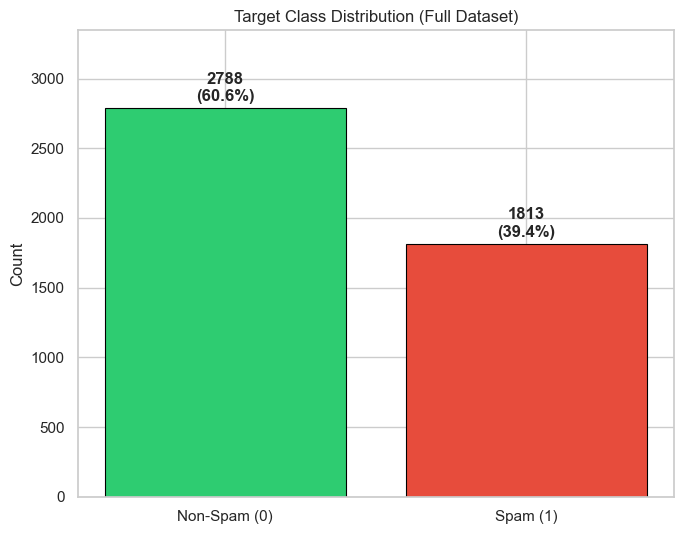

In [7]:
class_counts = df['spam'].value_counts().sort_index()
class_pct = df['spam'].value_counts(normalize=True).sort_index() * 100

print("Target Distribution (Full Dataset):")
print(f"  Non-Spam (0): {class_counts[0]:>5d}  ({class_pct[0]:.1f}%)")
print(f"  Spam    (1): {class_counts[1]:>5d}  ({class_pct[1]:.1f}%)")
print(f"  Total:        {len(df):>5d}")

fig, ax = plt.subplots(figsize=(7, 5.5))
colors = ['#2ecc71', '#e74c3c']
bars = ax.bar(['Non-Spam (0)', 'Spam (1)'], class_counts.values,
              color=colors, edgecolor='black', linewidth=0.8)
for bar, count, pct in zip(bars, class_counts.values, class_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 30,
            f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontweight='bold')
ax.set_ylabel('Count')
ax.set_title('Target Class Distribution (Full Dataset)')
ax.set_ylim(0, max(class_counts.values) * 1.2)
plt.tight_layout()
plt.show()

### 1.3 Missing Values Check

In [8]:
missing = df.isnull().sum()
total_missing = missing.sum()

print(f"Total missing values across all features: {total_missing}")
if total_missing > 0:
    print(f"\nFeatures with missing values:")
    print(missing[missing > 0].sort_values(ascending=False))
else:
    print("No missing values found -- the dataset is complete.")

Total missing values across all features: 0
No missing values found -- the dataset is complete.


### 1.4 Feature Distributions by Class

Visualize how key features differ between spam and non-spam emails.

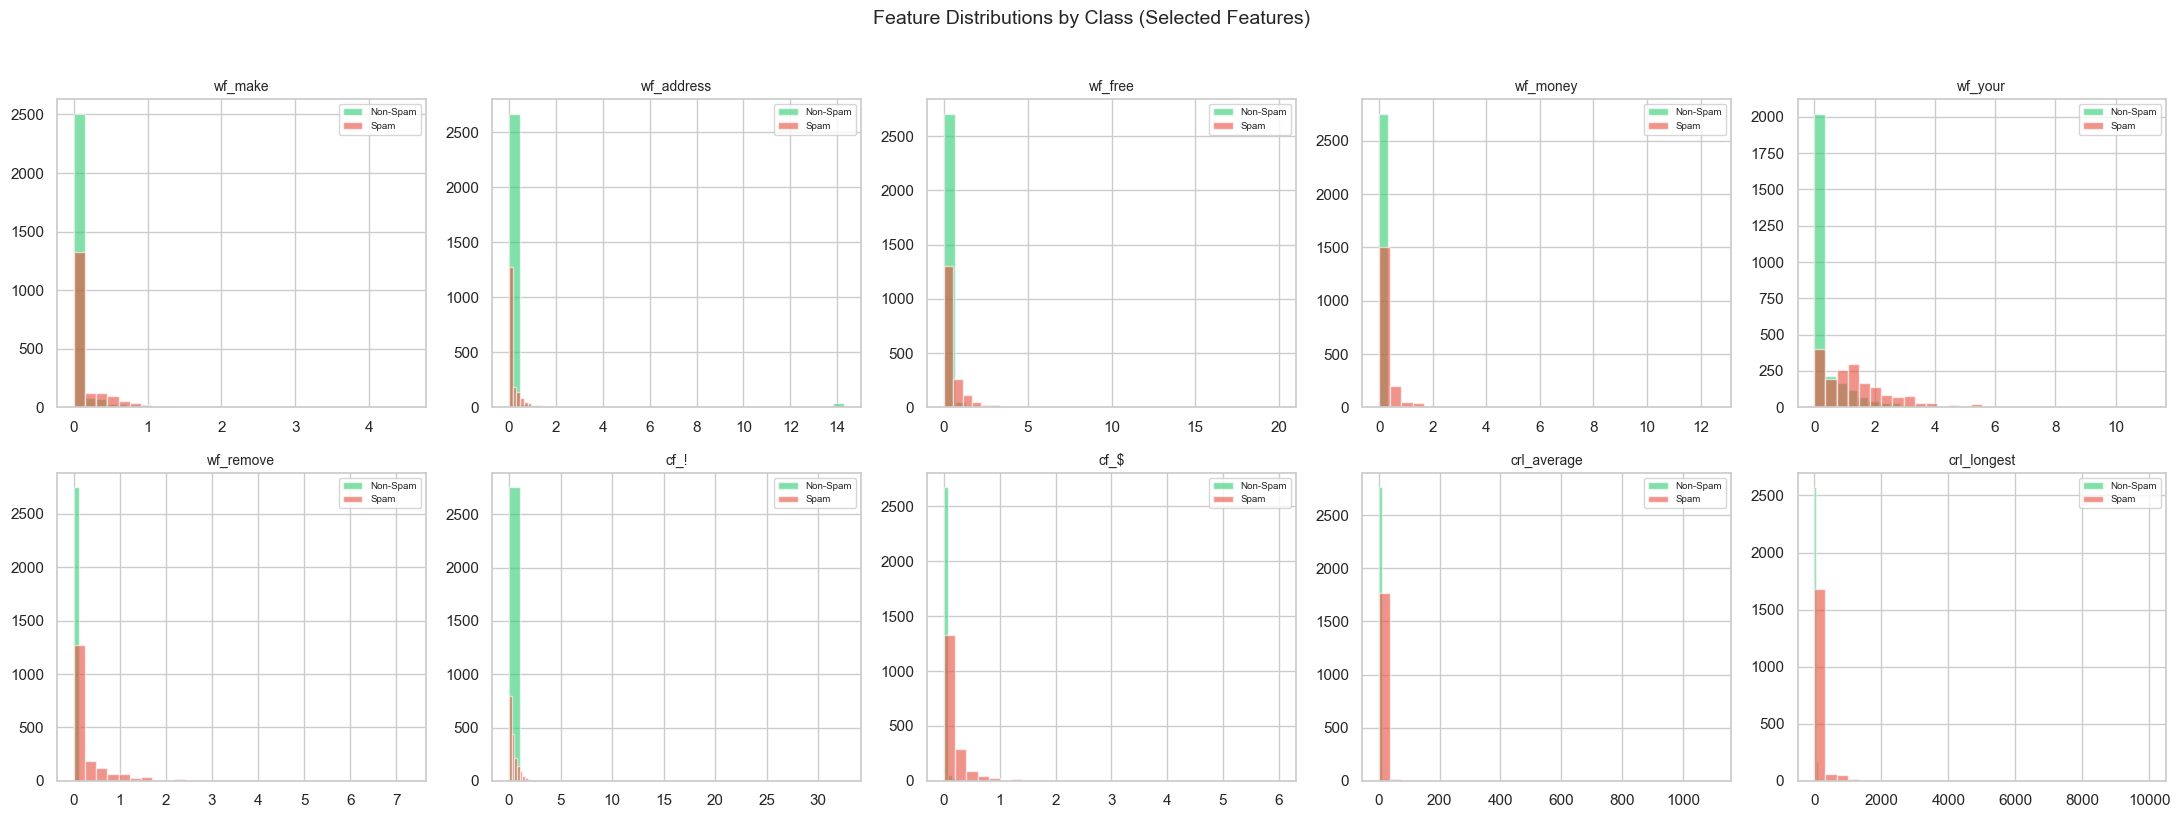

In [9]:
key_features = [
    'word_freq_make', 'word_freq_address', 'word_freq_free',
    'word_freq_money', 'word_freq_your', 'word_freq_remove',
    'char_freq_!', 'char_freq_$',
    'capital_run_length_average', 'capital_run_length_longest'
]

fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.ravel()

for i, feat in enumerate(key_features):
    ax = axes[i]
    df[df['spam'] == 0][feat].hist(bins=30, alpha=0.6, label='Non-Spam', ax=ax, color='#2ecc71')
    df[df['spam'] == 1][feat].hist(bins=30, alpha=0.6, label='Spam', ax=ax, color='#e74c3c')
    short = (feat.replace('word_freq_', 'wf_')
                 .replace('char_freq_', 'cf_')
                 .replace('capital_run_length_', 'crl_'))
    ax.set_title(short, fontsize=10)
    ax.legend(fontsize=7)

plt.suptitle('Feature Distributions by Class (Selected Features)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 1.5 Correlation Analysis

Identify features most correlated with the target and check for multicollinearity.

Top 15 features most correlated with target (absolute Pearson r):
  wf_your                        0.3832
  wf_000                         0.3348
  wf_remove                      0.3321
  cf_$                           0.3236
  wf_you                         0.2737
  wf_free                        0.2632
  wf_business                    0.2632
  wf_hp                          0.2567
  crl_total                      0.2492
  wf_our                         0.2419
  cf_!                           0.2419
  wf_receive                     0.2345
  wf_hpl                         0.2330
  wf_over                        0.2326
  wf_order                       0.2316


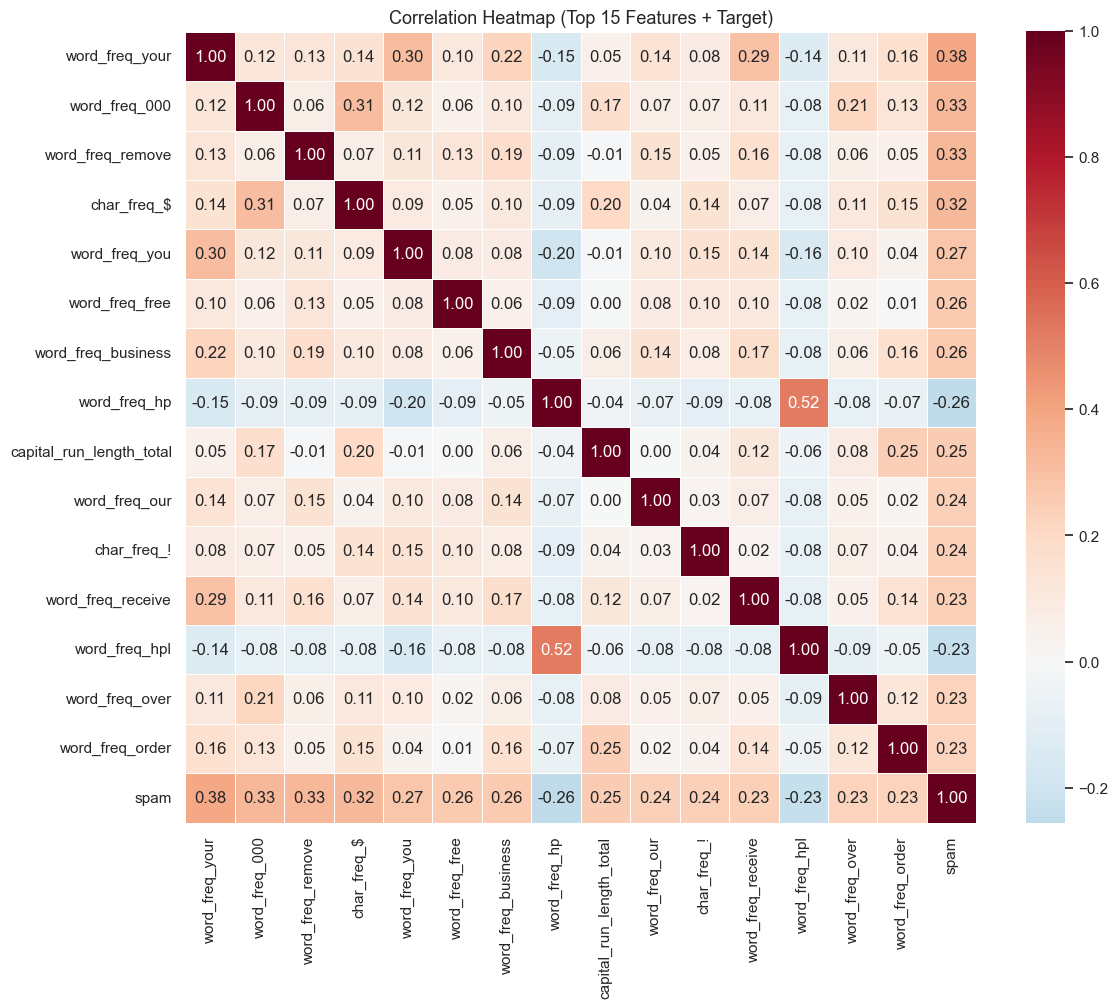

In [10]:
correlations = df.corr()['spam'].drop('spam').abs().sort_values(ascending=False)

print("Top 15 features most correlated with target (absolute Pearson r):")
for feat, corr in correlations.head(15).items():
    short = (feat.replace('word_freq_', 'wf_')
                 .replace('char_freq_', 'cf_')
                 .replace('capital_run_length_', 'crl_'))
    print(f"  {short:<30s} {corr:.4f}")

top_features = correlations.head(15).index.tolist()
fig, ax = plt.subplots(figsize=(12, 10))
corr_matrix = df[top_features + ['spam']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title('Correlation Heatmap (Top 15 Features + Target)', fontsize=13)
plt.tight_layout()
plt.show()

### 1.6 Top Discriminative Features (Boxplots)

Boxplots of the most discriminative features grouped by class.

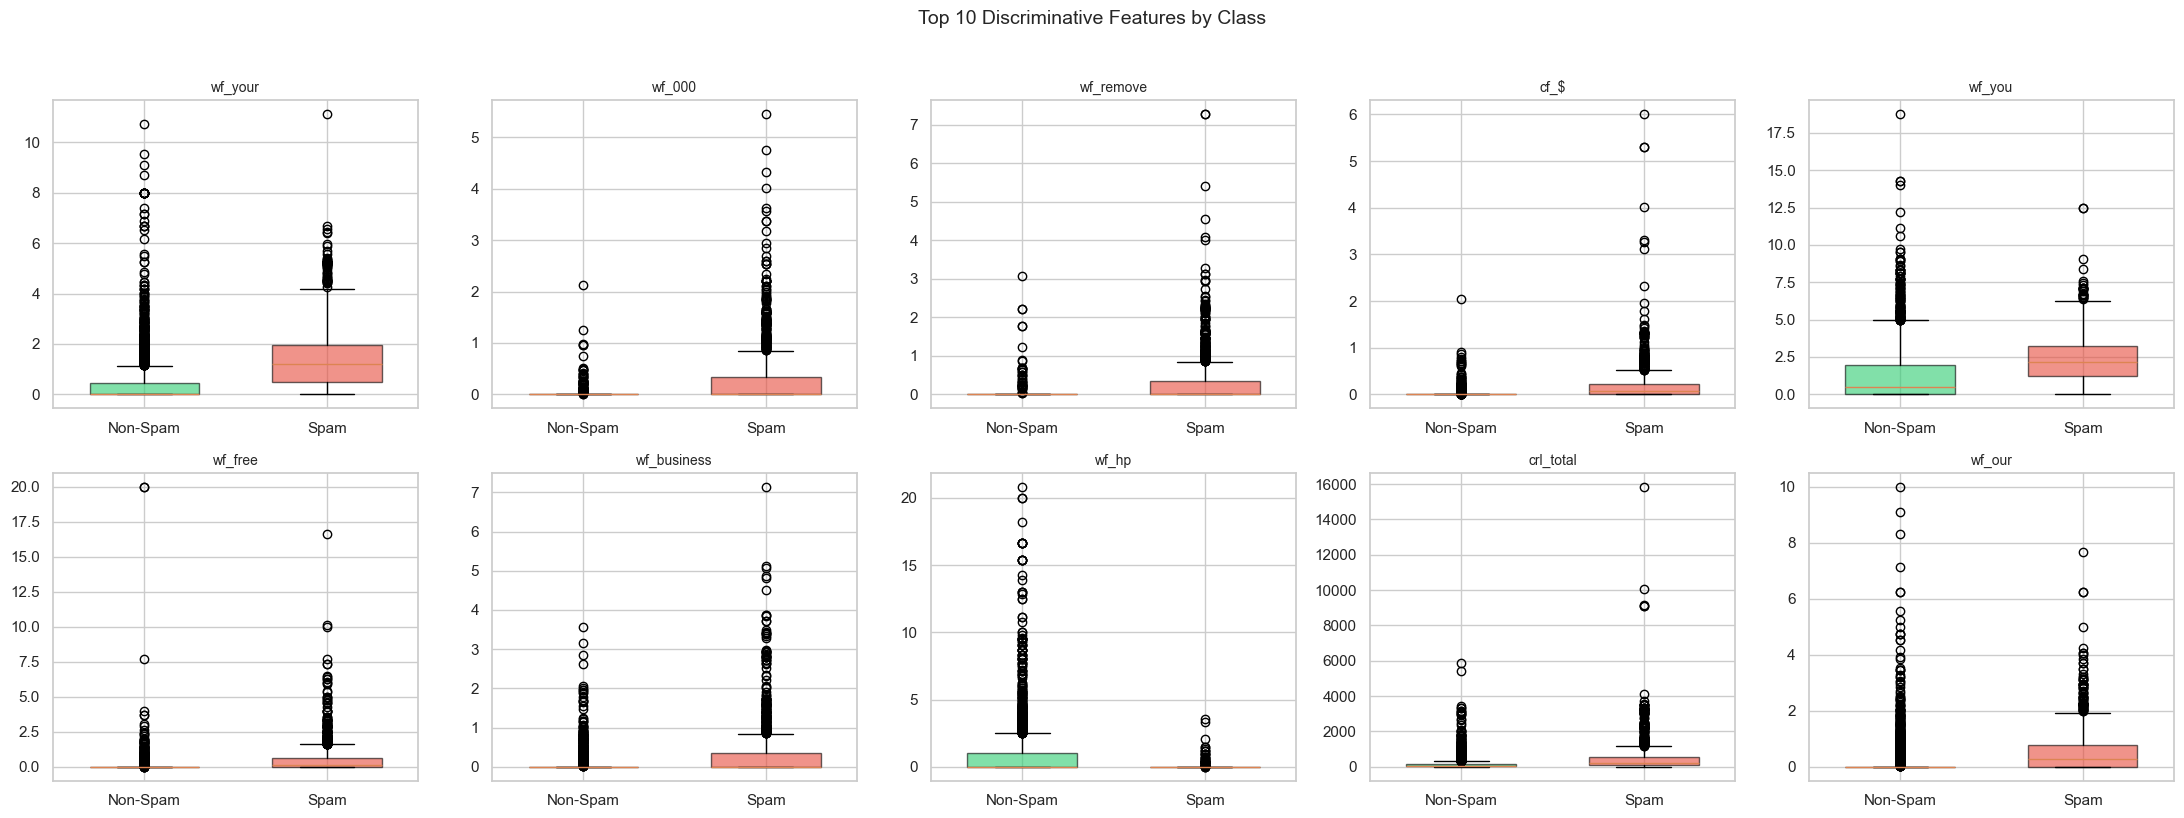

In [11]:
top10 = correlations.head(10).index.tolist()

fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.ravel()

for i, feat in enumerate(top10):
    ax = axes[i]
    data_plot = [df[df['spam'] == 0][feat], df[df['spam'] == 1][feat]]
    bp = ax.boxplot(data_plot, labels=['Non-Spam', 'Spam'], patch_artist=True,
                    widths=0.6)
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')
    for box in bp['boxes']:
        box.set_alpha(0.6)
    short = (feat.replace('word_freq_', 'wf_')
                 .replace('char_freq_', 'cf_')
                 .replace('capital_run_length_', 'crl_'))
    ax.set_title(short, fontsize=10)

plt.suptitle('Top 10 Discriminative Features by Class', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 2. Data Preprocessing

### 2.1 Train / Test Split

We use an 80/20 split with `stratify=y` to preserve the original class distribution in both sets.

In [12]:
X = df.drop('spam', axis=1)
y = df['spam']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples  ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"Test set:     {X_test.shape[0]} samples  ({X_test.shape[0]/len(df)*100:.1f}%)")

Training set: 3680 samples  (80.0%)
Test set:     921 samples  (20.0%)


### 2.2 Class Distribution in Train / Test Sets

Verify that stratification preserved the class balance across both sets.

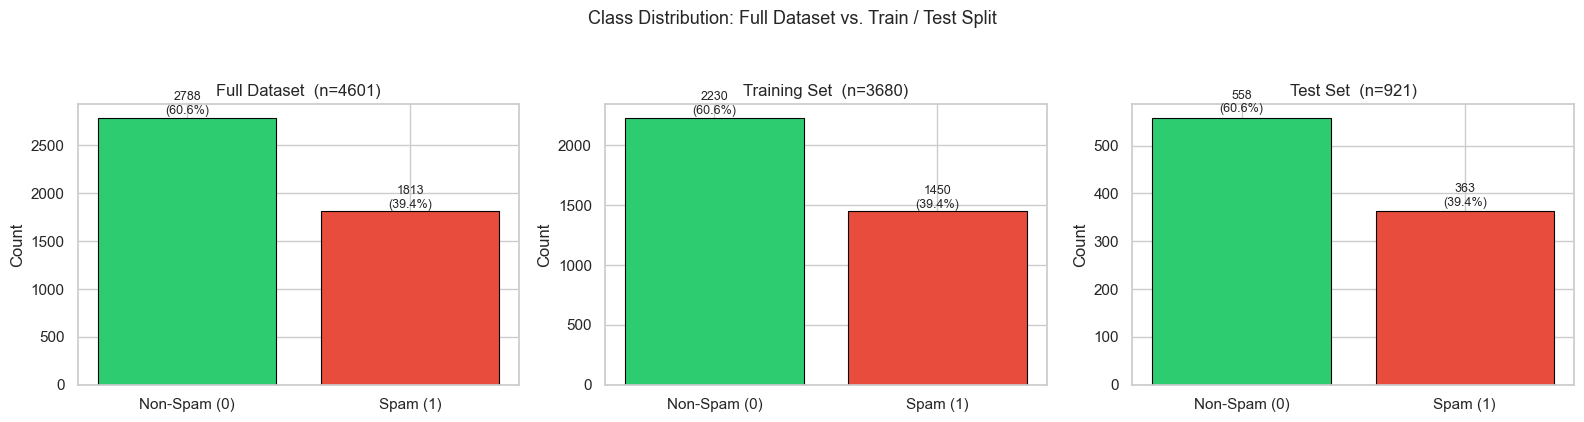

Class proportions preserved via stratified split ✓


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
colors = ['#2ecc71', '#e74c3c']

for ax, data, title in zip(axes,
                           [y, y_train, y_test],
                           ['Full Dataset', 'Training Set', 'Test Set']):
    counts = data.value_counts().sort_index()
    pcts = data.value_counts(normalize=True).sort_index() * 100
    bars = ax.bar(['Non-Spam (0)', 'Spam (1)'], counts.values,
                  color=colors, edgecolor='black', linewidth=0.8)
    for bar, count, pct in zip(bars, counts.values, pcts.values):
        ax.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 5,
                f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)
    ax.set_title(f'{title}  (n={len(data)})')
    ax.set_ylabel('Count')

plt.suptitle('Class Distribution: Full Dataset vs. Train / Test Split',
             fontsize=13, y=1.05)
plt.tight_layout()
plt.show()

print("Class proportions preserved via stratified split ✓")

### 2.3 Feature Scaling

StandardScaler is fitted on the **training set only** and then applied to both sets to prevent data leakage.

- **Scaled data** → Logistic Regression, SVM, KNN, Neural Network  
- **Unscaled data** → Decision Tree, Random Forest, XGBoost

In [14]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns, index=X_test.index
)

print("Feature scaling applied (StandardScaler).")
print(f"  Training set mean (first 5 features): {X_train_scaled.iloc[:, :5].mean().values.round(4)}")
print(f"  Training set std  (first 5 features): {X_train_scaled.iloc[:, :5].std().values.round(4)}")

Feature scaling applied (StandardScaler).
  Training set mean (first 5 features): [-0.  0.  0. -0.  0.]
  Training set std  (first 5 features): [1.0001 1.0001 1.0001 1.0001 1.0001]


## 3. Baseline Model

A dummy classifier that always predicts the majority class (non-spam) sets the floor that all subsequent models must beat.

Baseline Model (Always predict majority class):
  Accuracy:  0.6059
  Precision: 0.0000
  Recall:    0.0000
  F1 Score:  0.0000

→ All models must beat the baseline accuracy of 60.6%


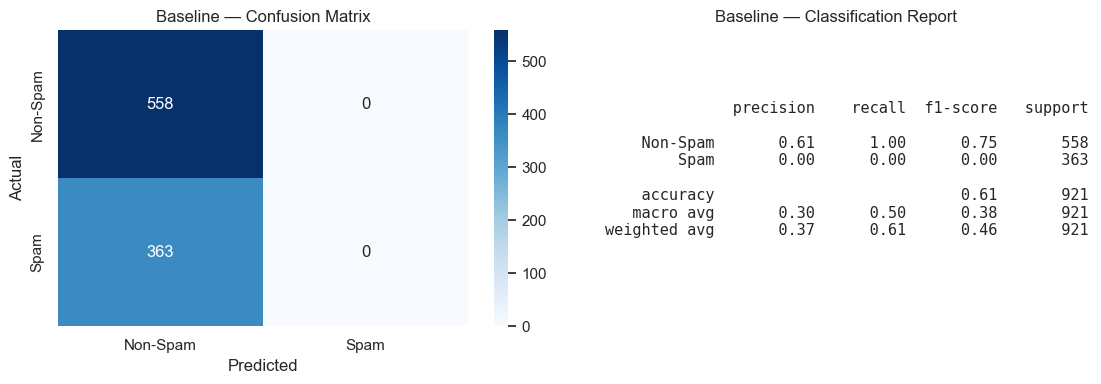

In [15]:
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

print("Baseline Model (Always predict majority class):")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_dummy):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_dummy, zero_division=0):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_dummy):.4f}")
print(f"  F1 Score:  {f1_score(y_test, y_pred_dummy):.4f}")
print(f"\n→ All models must beat the baseline accuracy of {accuracy_score(y_test, y_pred_dummy):.1%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cm = confusion_matrix(y_test, y_pred_dummy)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Non-Spam', 'Spam'], yticklabels=['Non-Spam', 'Spam'])
axes[0].set_title('Baseline — Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

report = classification_report(y_test, y_pred_dummy, target_names=['Non-Spam', 'Spam'])
axes[1].text(0.05, 0.5, report, fontsize=11, fontfamily='monospace',
             verticalalignment='center', transform=axes[1].transAxes)
axes[1].axis('off')
axes[1].set_title('Baseline — Classification Report')
plt.tight_layout()
plt.show()

## 4. Model Training and Evaluation

Each model is evaluated using:
1. **Stratified 5-Fold Cross-Validation** on the training set (mean ± std)
2. **Hold-out test set** evaluation

Metrics: Accuracy, Precision, Recall, F1 Score, ROC-AUC

### Class Distribution in K-Fold Cross-Validation

Verify that `StratifiedKFold` preserves the class balance in every fold's training and validation partition.

Class distribution per CV fold (on training set):

  Fold   | Train Spam % |   Val Spam % | Train Size |   Val Size
  ------ | ------------ | ------------ | ---------- | ----------
  Fold 1 |        39.4% |        39.4% |       2944 |        736
  Fold 2 |        39.4% |        39.4% |       2944 |        736
  Fold 3 |        39.4% |        39.4% |       2944 |        736
  Fold 4 |        39.4% |        39.4% |       2944 |        736
  Fold 5 |        39.4% |        39.4% |       2944 |        736

  Overall training set spam rate: 39.4%
  Max fold deviation from overall: 0.00%

  → Stratified K-Fold preserves class balance across all folds ✓


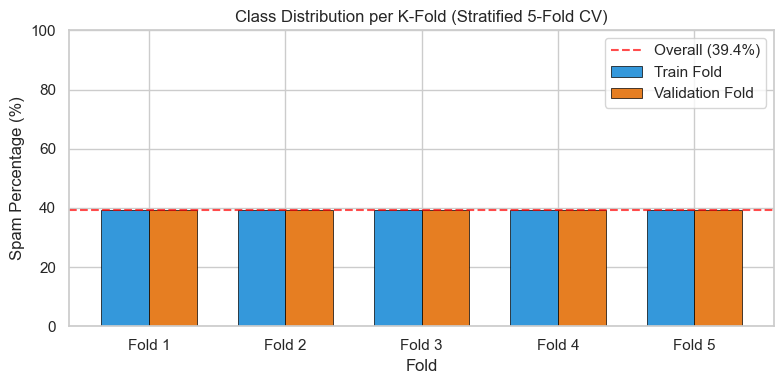

In [16]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Class distribution per CV fold (on training set):\n")
print(f"  {'Fold':<6s} | {'Train Spam %':>12s} | {'Val Spam %':>12s} | {'Train Size':>10s} | {'Val Size':>10s}")
print(f"  {'-'*6} | {'-'*12} | {'-'*12} | {'-'*10} | {'-'*10}")

fold_train_pcts = []
fold_val_pcts = []

for i, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]
    train_pct = y_fold_train.mean() * 100
    val_pct = y_fold_val.mean() * 100
    fold_train_pcts.append(train_pct)
    fold_val_pcts.append(val_pct)
    print(f"  Fold {i+1} | {train_pct:>11.1f}% | {val_pct:>11.1f}% | {len(y_fold_train):>10d} | {len(y_fold_val):>10d}")

print(f"\n  Overall training set spam rate: {y_train.mean()*100:.1f}%")
print(f"  Max fold deviation from overall: {max(abs(p - y_train.mean()*100) for p in fold_val_pcts):.2f}%")
print("\n  → Stratified K-Fold preserves class balance across all folds ✓")

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(5)
width = 0.35
bars1 = ax.bar(x - width/2, fold_train_pcts, width, label='Train Fold', color='#3498db', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x + width/2, fold_val_pcts, width, label='Validation Fold', color='#e67e22', edgecolor='black', linewidth=0.5)
ax.axhline(y=y_train.mean()*100, color='red', linestyle='--', alpha=0.7, label=f'Overall ({y_train.mean()*100:.1f}%)')
ax.set_xlabel('Fold')
ax.set_ylabel('Spam Percentage (%)')
ax.set_title('Class Distribution per K-Fold (Stratified 5-Fold CV)')
ax.set_xticks(x)
ax.set_xticklabels([f'Fold {i+1}' for i in range(5)])
ax.legend()
ax.set_ylim([0, 100])
plt.tight_layout()
plt.show()

### Evaluation Helper Function

In [17]:
results = []
fitted_models = {}
scaled_model_names = set()

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te, cv=5, is_scaled=False):
    """Train model, run stratified k-fold CV on training data, evaluate on test set."""

    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
    scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
    cv_res = cross_validate(model, X_tr, y_tr, cv=skf, scoring=scoring)

    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = (model.predict_proba(X_te)[:, 1]
              if hasattr(model, 'predict_proba')
              else model.decision_function(X_te))

    row = {
        'Model': name,
        'CV Accuracy':  f"{cv_res['test_accuracy'].mean():.4f} ± {cv_res['test_accuracy'].std():.4f}",
        'CV Precision': f"{cv_res['test_precision'].mean():.4f} ± {cv_res['test_precision'].std():.4f}",
        'CV Recall':    f"{cv_res['test_recall'].mean():.4f} ± {cv_res['test_recall'].std():.4f}",
        'CV F1':        f"{cv_res['test_f1'].mean():.4f} ± {cv_res['test_f1'].std():.4f}",
        'CV ROC-AUC':   f"{cv_res['test_roc_auc'].mean():.4f} ± {cv_res['test_roc_auc'].std():.4f}",
        'Test Accuracy':  accuracy_score(y_te, y_pred),
        'Test Precision': precision_score(y_te, y_pred),
        'Test Recall':    recall_score(y_te, y_pred),
        'Test F1':        f1_score(y_te, y_pred),
        'Test ROC-AUC':   roc_auc_score(y_te, y_prob),
    }
    results.append(row)
    fitted_models[name] = model
    if is_scaled:
        scaled_model_names.add(name)

    print(f"{'=' * 60}")
    print(f"  {name}")
    print(f"{'=' * 60}")
    print(f"\nCross-Validation (Stratified {cv}-Fold):")
    for m in scoring:
        s = cv_res[f'test_{m}']
        print(f"  {m:>12s}: {s.mean():.4f} ± {s.std():.4f}")
    print(f"\nTest Set Results:")
    print(f"  {'Accuracy':>12s}: {row['Test Accuracy']:.4f}")
    print(f"  {'Precision':>12s}: {row['Test Precision']:.4f}")
    print(f"  {'Recall':>12s}: {row['Test Recall']:.4f}")
    print(f"  {'F1':>12s}: {row['Test F1']:.4f}")
    print(f"  {'ROC-AUC':>12s}: {row['Test ROC-AUC']:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    cm = confusion_matrix(y_te, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Non-Spam', 'Spam'],
                yticklabels=['Non-Spam', 'Spam'])
    axes[0].set_title(f'{name} — Confusion Matrix')
    axes[0].set_ylabel('Actual')
    axes[0].set_xlabel('Predicted')

    report = classification_report(y_te, y_pred, target_names=['Non-Spam', 'Spam'])
    axes[1].text(0.05, 0.5, report, fontsize=11, fontfamily='monospace',
                 verticalalignment='center', transform=axes[1].transAxes)
    axes[1].axis('off')
    axes[1].set_title(f'{name} — Classification Report')
    plt.tight_layout()
    plt.show()

    return model

### 4.1 Logistic Regression

  Logistic Regression

Cross-Validation (Stratified 5-Fold):
      accuracy: 0.9234 ± 0.0109
     precision: 0.9212 ± 0.0208
        recall: 0.8814 ± 0.0171
            f1: 0.9007 ± 0.0138
       roc_auc: 0.9705 ± 0.0061

Test Set Results:
      Accuracy: 0.9294
     Precision: 0.9209
        Recall: 0.8981
            F1: 0.9093
       ROC-AUC: 0.9702


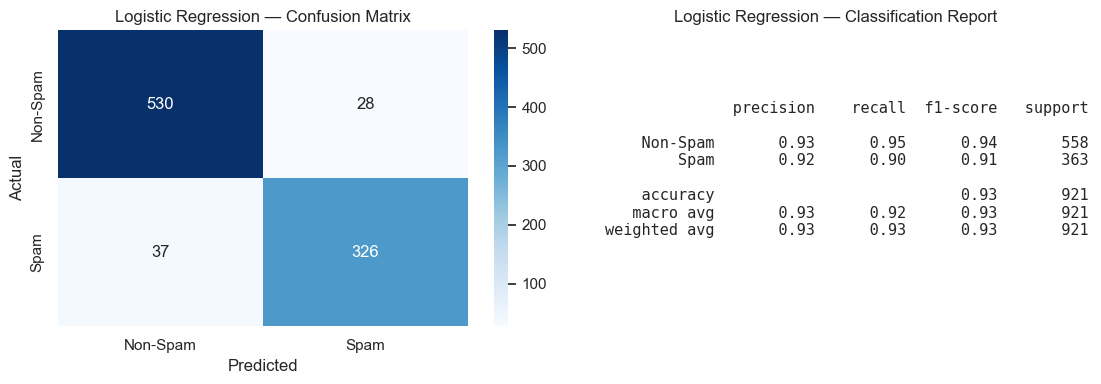

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [18]:
lr = LogisticRegression(max_iter=1000, random_state=42)
evaluate_model('Logistic Regression', lr,
               X_train_scaled, X_test_scaled, y_train, y_test, is_scaled=True)

### 4.2 Decision Tree

  Decision Tree

Cross-Validation (Stratified 5-Fold):
      accuracy: 0.9136 ± 0.0097
     precision: 0.8865 ± 0.0187
        recall: 0.8959 ± 0.0171
            f1: 0.8910 ± 0.0120
       roc_auc: 0.9105 ± 0.0098

Test Set Results:
      Accuracy: 0.9110
     Precision: 0.8828
        Recall: 0.8926
            F1: 0.8877
       ROC-AUC: 0.9078


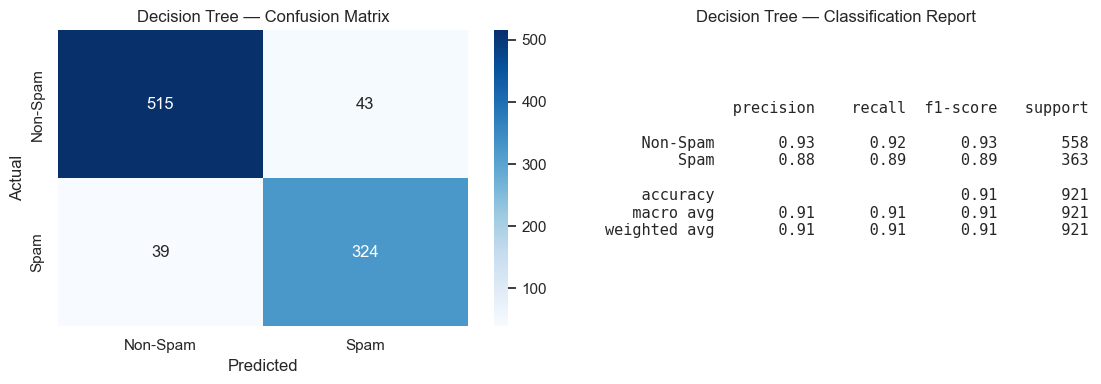

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [19]:
dt = DecisionTreeClassifier(random_state=42)
evaluate_model('Decision Tree', dt,
               X_train, X_test, y_train, y_test)

### 4.3 Random Forest

  Random Forest

Cross-Validation (Stratified 5-Fold):
      accuracy: 0.9511 ± 0.0060
     precision: 0.9503 ± 0.0023
        recall: 0.9241 ± 0.0148
            f1: 0.9370 ± 0.0081
       roc_auc: 0.9859 ± 0.0040

Test Set Results:
      Accuracy: 0.9457
     Precision: 0.9510
        Recall: 0.9091
            F1: 0.9296
       ROC-AUC: 0.9833


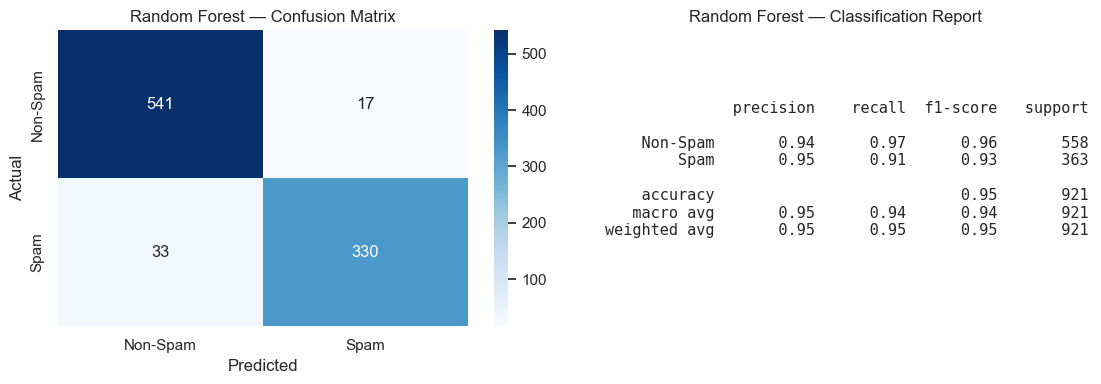

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [20]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
evaluate_model('Random Forest', rf,
               X_train, X_test, y_train, y_test)

### 4.4 XGBoost

  XGBoost

Cross-Validation (Stratified 5-Fold):
      accuracy: 0.9563 ± 0.0079
     precision: 0.9467 ± 0.0073
        recall: 0.9421 ± 0.0178
            f1: 0.9443 ± 0.0104
       roc_auc: 0.9875 ± 0.0031

Test Set Results:
      Accuracy: 0.9457
     Precision: 0.9359
        Recall: 0.9256
            F1: 0.9307
       ROC-AUC: 0.9874


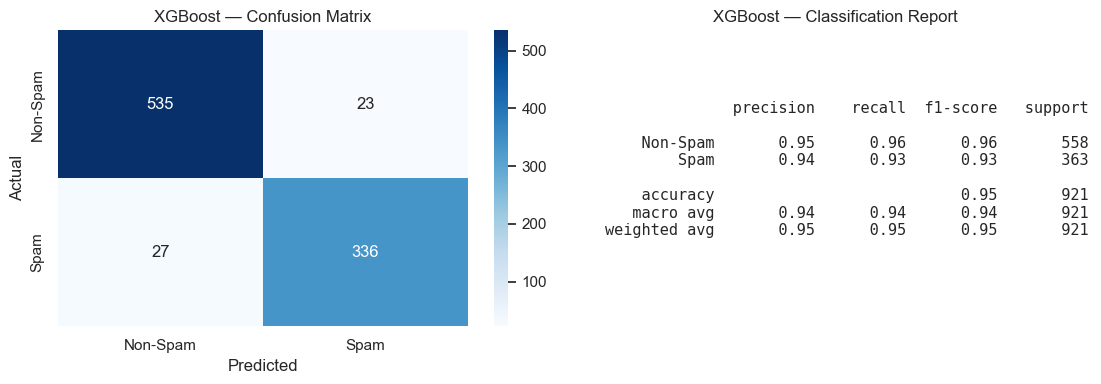

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [21]:
xgb = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    random_state=42, eval_metric='logloss', verbosity=0
)
evaluate_model('XGBoost', xgb,
               X_train, X_test, y_train, y_test)

### 4.5 K-Nearest Neighbors

Exception in thread Thread-383 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\pschr\anaconda3\envs\AI_and_DL_Project\Lib\threading.py", line 1082, in _bootstrap_inner
    self._context.run(self.run)
    ~~~~~~~~~~~~~~~~~^^^^^^^^^^
  File "c:\Users\pschr\anaconda3\envs\AI_and_DL_Project\Lib\threading.py", line 1024, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\pschr\anaconda3\envs\AI_and_DL_Project\Lib\subprocess.py", line 1613, in _readerthread
    buffer.append(fh.read())
                  ~~~~~~~^^
  File "<frozen codecs>", line 325, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0x81 in position 120: invalid start byte


  KNN

Cross-Validation (Stratified 5-Fold):
      accuracy: 0.9054 ± 0.0049
     precision: 0.8985 ± 0.0160
        recall: 0.8572 ± 0.0104
            f1: 0.8772 ± 0.0054
       roc_auc: 0.9530 ± 0.0051

Test Set Results:
      Accuracy: 0.9077
     Precision: 0.8861
        Recall: 0.8788
            F1: 0.8824
       ROC-AUC: 0.9506


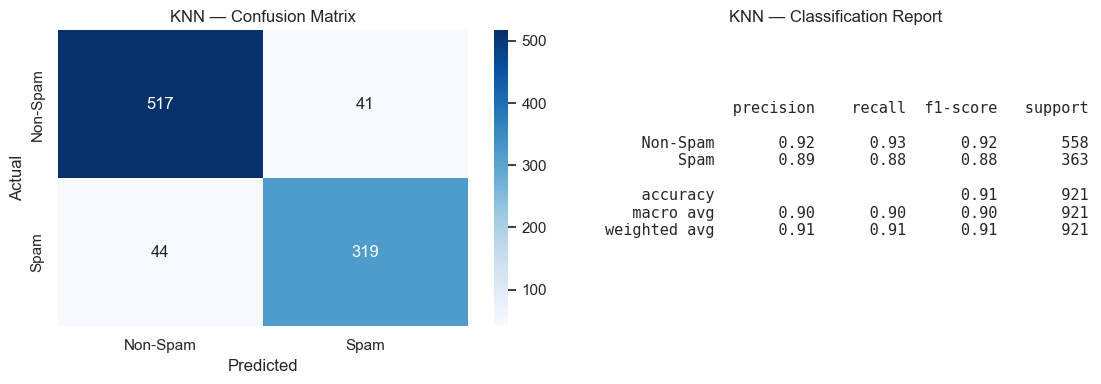

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",-1


In [22]:
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
evaluate_model('KNN', knn,
               X_train_scaled, X_test_scaled, y_train, y_test, is_scaled=True)

### 4.6 Support Vector Machine

  SVM

Cross-Validation (Stratified 5-Fold):
      accuracy: 0.9318 ± 0.0071
     precision: 0.9341 ± 0.0056
        recall: 0.8897 ± 0.0150
            f1: 0.9113 ± 0.0097
       roc_auc: 0.9730 ± 0.0031

Test Set Results:
      Accuracy: 0.9273
     Precision: 0.9277
        Recall: 0.8843
            F1: 0.9055
       ROC-AUC: 0.9667


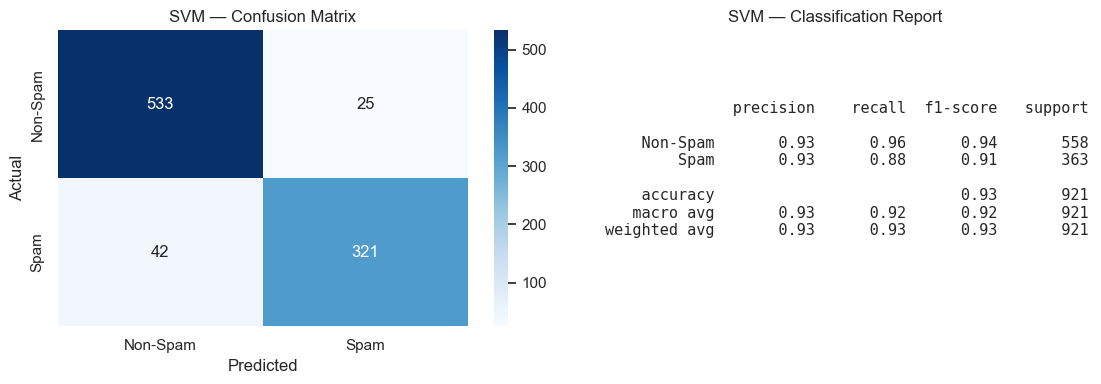

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [23]:
svm = SVC(kernel='rbf', probability=True, random_state=42)
evaluate_model('SVM', svm,
               X_train_scaled, X_test_scaled, y_train, y_test, is_scaled=True)

### 4.7 Neural Network (MLP)

  Neural Network (MLP)

Cross-Validation (Stratified 5-Fold):
      accuracy: 0.9424 ± 0.0036
     precision: 0.9312 ± 0.0075
        recall: 0.9221 ± 0.0125
            f1: 0.9265 ± 0.0050
       roc_auc: 0.9784 ± 0.0055

Test Set Results:
      Accuracy: 0.9392
     Precision: 0.9324
        Recall: 0.9118
            F1: 0.9220
       ROC-AUC: 0.9827


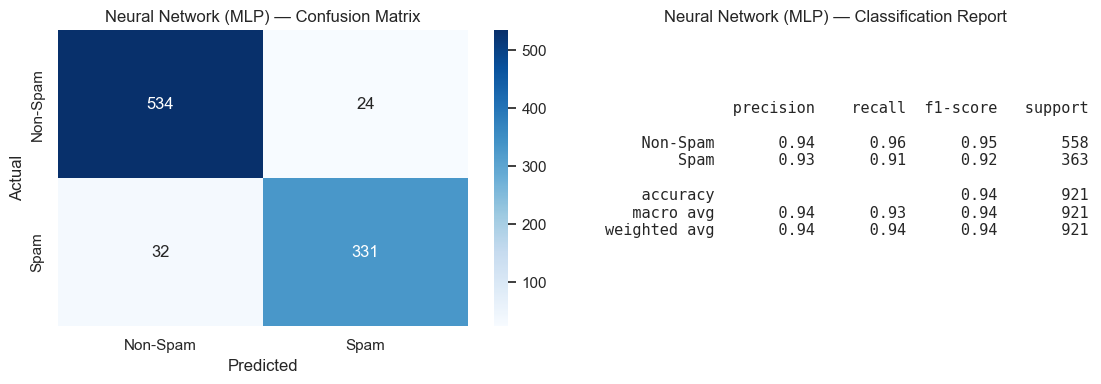

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(128, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


In [24]:
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64), max_iter=500,
    random_state=42, early_stopping=True, validation_fraction=0.15
)
evaluate_model('Neural Network (MLP)', mlp,
               X_train_scaled, X_test_scaled, y_train, y_test, is_scaled=True)

## 5. Model Comparison

### 5.1 Results Table

In [25]:
results_df = pd.DataFrame(results)
results_df.set_index('Model', inplace=False)

,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC-AUC,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC
Model,,,,,,,,,,
Logistic Regression,0.9234 ± 0.0109,0.9212 ± 0.0208,0.8814 ± 0.0171,0.9007 ± 0.0138,0.9705 ± 0.0061,0.929425,0.920904,0.898072,0.909344,0.970196
Decision Tree,0.9136 ± 0.0097,0.8865 ± 0.0187,0.8959 ± 0.0171,0.8910 ± 0.0120,0.9105 ± 0.0098,0.910966,0.882834,0.892562,0.887671,0.907751
Random Forest,0.9511 ± 0.0060,0.9503 ± 0.0023,0.9241 ± 0.0148,0.9370 ± 0.0081,0.9859 ± 0.0040,0.945711,0.951009,0.909091,0.929577,0.983325
XGBoost,0.9563 ± 0.0079,0.9467 ± 0.0073,0.9421 ± 0.0178,0.9443 ± 0.0104,0.9875 ± 0.0031,0.945711,0.935933,0.925620,0.930748,0.987421
KNN,0.9054 ± 0.0049,0.8985 ± 0.0160,0.8572 ± 0.0104,0.8772 ± 0.0054,0.9530 ± 0.0051,0.907709,0.886111,0.878788,0.882434,0.950564
SVM,0.9318 ± 0.0071,0.9341 ± 0.0056,0.8897 ± 0.0150,0.9113 ± 0.0097,0.9730 ± 0.0031,0.927253,0.927746,0.884298,0.905501,0.966685
Neural Network (MLP),0.9424 ± 0.0036,0.9312 ± 0.0075,0.9221 ± 0.0125,0.9265 ± 0.0050,0.9784 ± 0.0055,0.939197,0.932394,0.911846,0.922006,0.982681


### 5.2 Visual Comparison (Test Set Metrics)

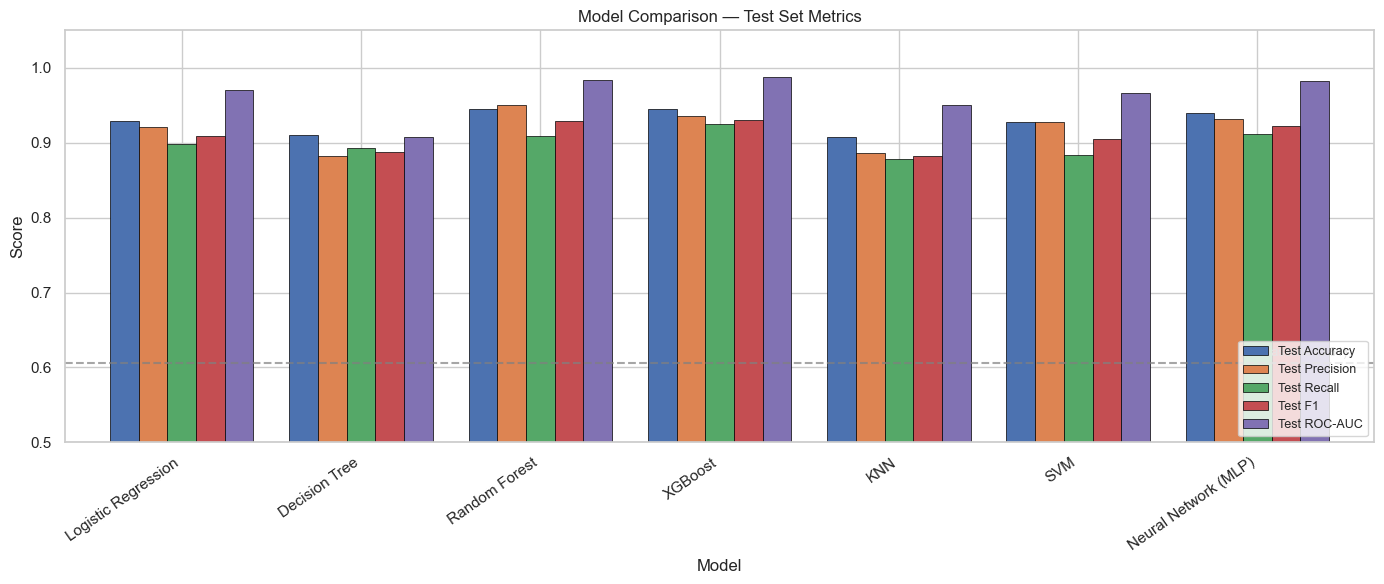

In [26]:
test_cols = ['Test Accuracy', 'Test Precision', 'Test Recall', 'Test F1', 'Test ROC-AUC']
plot_df = results_df.set_index('Model')[test_cols]

fig, ax = plt.subplots(figsize=(14, 6))
plot_df.plot(kind='bar', ax=ax, width=0.8, edgecolor='black', linewidth=0.5)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Test Set Metrics')
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
ax.legend(loc='lower right', fontsize=9)
ax.set_ylim([0.5, 1.05])

baseline_acc = accuracy_score(y_test, dummy.predict(X_test))
ax.axhline(y=baseline_acc, color='gray', linestyle='--', alpha=0.7, label='Baseline')
ax.text(len(plot_df) - 0.5, baseline_acc + 0.01, f'Baseline ({baseline_acc:.2f})',
        color='gray', fontsize=9, ha='right')
plt.tight_layout()
plt.show()

### 5.3 ROC Curves

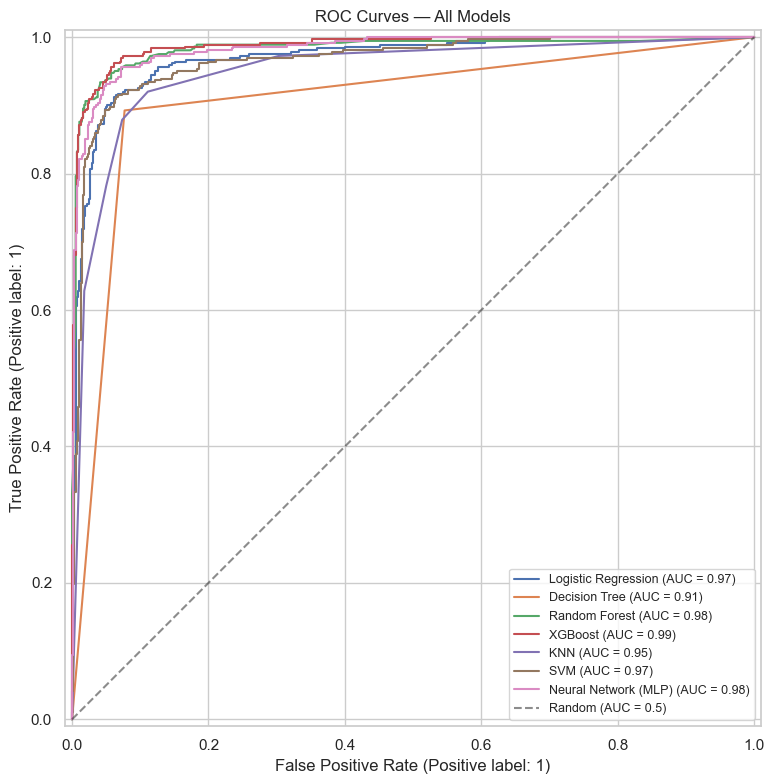

In [27]:
fig, ax = plt.subplots(figsize=(10, 8))

for name, model in fitted_models.items():
    X_te = X_test_scaled if name in scaled_model_names else X_test
    RocCurveDisplay.from_estimator(model, X_te, y_test, ax=ax, name=name)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random (AUC = 0.5)')
ax.set_title('ROC Curves — All Models')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

### 5.4 Discussion

Key observations from the model comparison:

- **Best overall model**: Determined by the highest Test F1 score, balancing precision and recall.
- **Precision vs. Recall trade-off**: In spam filtering, false positives (legitimate emails classified as spam) are particularly costly, as users may lose important messages. Models with high precision are preferred.
- **Cross-validation consistency**: Models with low CV standard deviation are more reliable and less prone to overfitting.
- **Tree-based models** (Random Forest, XGBoost) typically perform well on tabular data without requiring feature scaling.
- **Neural Network (MLP)** can capture complex non-linear relationships but may require more careful tuning.

## 6. Feature Importance

Analyze which features contribute most to the classification decision.

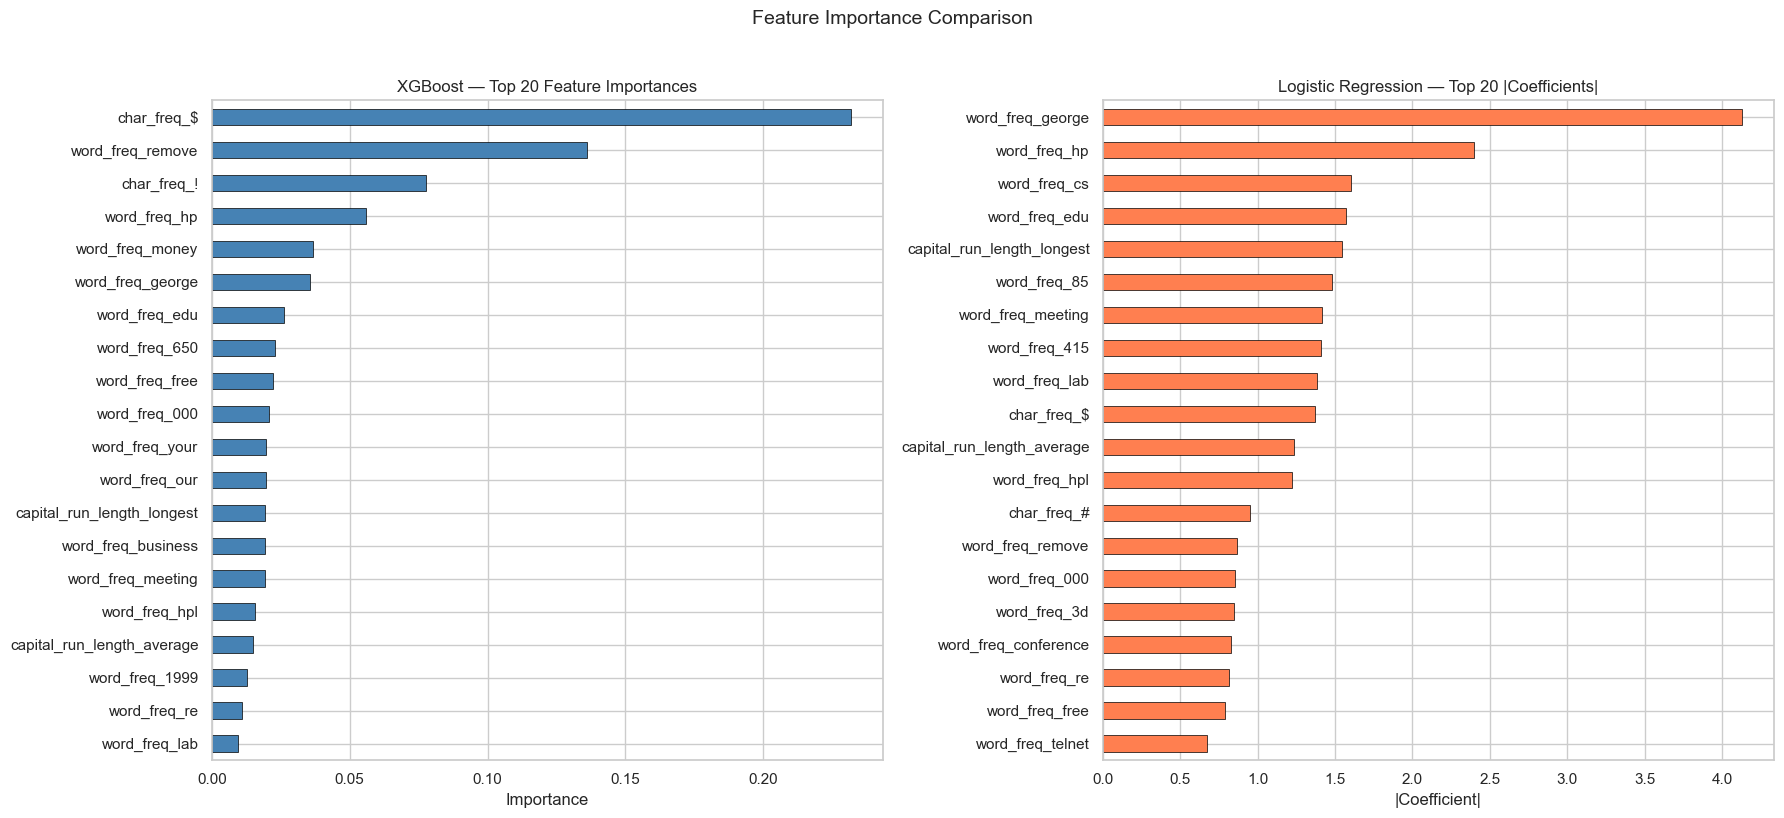

Top 10 features by XGBoost importance:
  char_freq_$                              0.2318
  word_freq_remove                         0.1359
  char_freq_!                              0.0777
  word_freq_hp                             0.0558
  word_freq_money                          0.0369
  word_freq_george                         0.0356
  word_freq_edu                            0.0262
  word_freq_650                            0.0228
  word_freq_free                           0.0221
  word_freq_000                            0.0207

Top 10 features by Logistic Regression |coefficient|:
  word_freq_george                         4.1296
  word_freq_hp                             2.4010
  word_freq_cs                             1.6059
  word_freq_edu                            1.5690
  capital_run_length_longest               1.5475
  word_freq_85                             1.4789
  word_freq_meeting                        1.4169
  word_freq_415                            1.4070
  word

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# XGBoost feature importances
xgb_model = fitted_models['XGBoost']
xgb_imp = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
xgb_imp = xgb_imp.sort_values(ascending=True)
xgb_imp.tail(20).plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='black', linewidth=0.5)
axes[0].set_title('XGBoost — Top 20 Feature Importances')
axes[0].set_xlabel('Importance')

# Logistic Regression absolute coefficients
lr_model = fitted_models['Logistic Regression']
lr_coef = pd.Series(np.abs(lr_model.coef_[0]), index=X_train.columns)
lr_coef = lr_coef.sort_values(ascending=True)
lr_coef.tail(20).plot(kind='barh', ax=axes[1], color='coral', edgecolor='black', linewidth=0.5)
axes[1].set_title('Logistic Regression — Top 20 |Coefficients|')
axes[1].set_xlabel('|Coefficient|')

plt.suptitle('Feature Importance Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Print top 10 from each
print("Top 10 features by XGBoost importance:")
for feat, imp in xgb_imp.sort_values(ascending=False).head(10).items():
    print(f"  {feat:<40s} {imp:.4f}")

print(f"\nTop 10 features by Logistic Regression |coefficient|:")
for feat, coef in lr_coef.sort_values(ascending=False).head(10).items():
    print(f"  {feat:<40s} {coef:.4f}")

## 7. Bonus: External Validation on Real-World Emails

To test how well our trained models generalize, we apply the best model to the [Enron Spam Dataset](https://github.com/MWiechmann/enron_spam_data) — a collection of 33,716 real emails with spam/ham labels.

Since the Spambase dataset contains **pre-computed features** (word frequencies, character frequencies, capital run lengths), we must **re-engineer the same 57 features** from the raw email text.

### 7.1 Download and Load Enron Dataset

In [31]:
import requests
import zipfile
import io
import re

enron_url = "https://github.com/MWiechmann/enron_spam_data/raw/master/enron_spam_data.zip"
print("Downloading Enron Spam Dataset...")
response = requests.get(enron_url)

with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    csv_name = [f for f in z.namelist() if f.endswith('.csv')][0]
    with z.open(csv_name) as f:
        enron_df = pd.read_csv(f)

print(f"Enron Dataset shape: {enron_df.shape}")
print(f"Columns: {enron_df.columns.tolist()}")

enron_df['label'] = (enron_df['Spam/Ham'] == 'spam').astype(int)

enron_counts = enron_df['label'].value_counts().sort_index()
enron_pcts = enron_df['label'].value_counts(normalize=True).sort_index() * 100

print(f"\nEnron Target Distribution:")
print(f"  Ham  (0): {enron_counts[0]:>6d}  ({enron_pcts[0]:.1f}%)")
print(f"  Spam (1): {enron_counts[1]:>6d}  ({enron_pcts[1]:.1f}%)")
enron_df.head()

Enron Dataset shape: (33716, 5)
Columns: ['Message ID', 'Subject', 'Message', 'Spam/Ham', 'Date']

Enron Target Distribution:
  Ham  (0):  16545  (49.1%)
  Spam (1):  17171  (50.9%)


,Message ID,Subject,Message,Spam/Ham,Date,label
0,0,christmas tree farm pictures,NaN,ham,1999-12-10,0
1,1,"vastar resources , inc .","gary , production from the high island larger ...",ham,1999-12-13,0
2,2,calpine daily gas nomination,- calpine daily gas nomination 1 . doc,ham,1999-12-14,0
3,3,re : issue,fyi - see note below - already done .\nstella\...,ham,1999-12-14,0
4,4,meter 7268 nov allocation,fyi .\n- - - - - - - - - - - - - - - - - - - -...,ham,1999-12-14,0


### 7.2 Feature Engineering

Extract the same 57 features that the Spambase dataset uses from the raw email text.

In [32]:
SPAMBASE_WORDS = [
    'make', 'address', 'all', '3d', 'our', 'over', 'remove', 'internet',
    'order', 'mail', 'receive', 'will', 'people', 'report', 'addresses',
    'free', 'business', 'email', 'you', 'credit', 'your', 'font', '000',
    'money', 'hp', 'hpl', 'george', '650', 'lab', 'labs', 'telnet', '857',
    'data', '415', '85', 'technology', '1999', 'parts', 'pm', 'direct',
    'cs', 'meeting', 'original', 'project', 're', 'edu', 'table', 'conference'
]

SPAMBASE_CHARS = [';', '(', '[', '!', '$', '#']


def extract_spambase_features(text):
    """Extract the 57 Spambase-compatible features from raw email text."""
    if not isinstance(text, str) or len(text.strip()) == 0:
        return [0.0] * 57

    words = re.findall(r'[a-zA-Z0-9]+', text.lower())
    total_words = max(len(words), 1)
    word_freqs = [100.0 * words.count(w.lower()) / total_words for w in SPAMBASE_WORDS]

    total_chars = max(len(text), 1)
    char_freqs = [100.0 * text.count(c) / total_chars for c in SPAMBASE_CHARS]

    cap_runs = re.findall(r'[A-Z]+', text)
    if cap_runs:
        run_lengths = [len(r) for r in cap_runs]
        crl_avg = np.mean(run_lengths)
        crl_max = max(run_lengths)
        crl_total = sum(run_lengths)
    else:
        crl_avg, crl_max, crl_total = 1.0, 1, 1

    return word_freqs + char_freqs + [crl_avg, crl_max, crl_total]


print(f"Feature engineering function defined.")
print(f"  Word features: {len(SPAMBASE_WORDS)}")
print(f"  Char features: {len(SPAMBASE_CHARS)}")
print(f"  Capital run length features: 3")
print(f"  Total features: {len(SPAMBASE_WORDS) + len(SPAMBASE_CHARS) + 3}")

Feature engineering function defined.
  Word features: 48
  Char features: 6
  Capital run length features: 3
  Total features: 57


### 7.3 Apply to Enron Sample and Evaluate

Extracting Spambase features from 1000 Enron emails...

Enron Sample Target Distribution:
  Ham  (0):  491  (49.1%)
  Spam (1):  509  (50.9%)


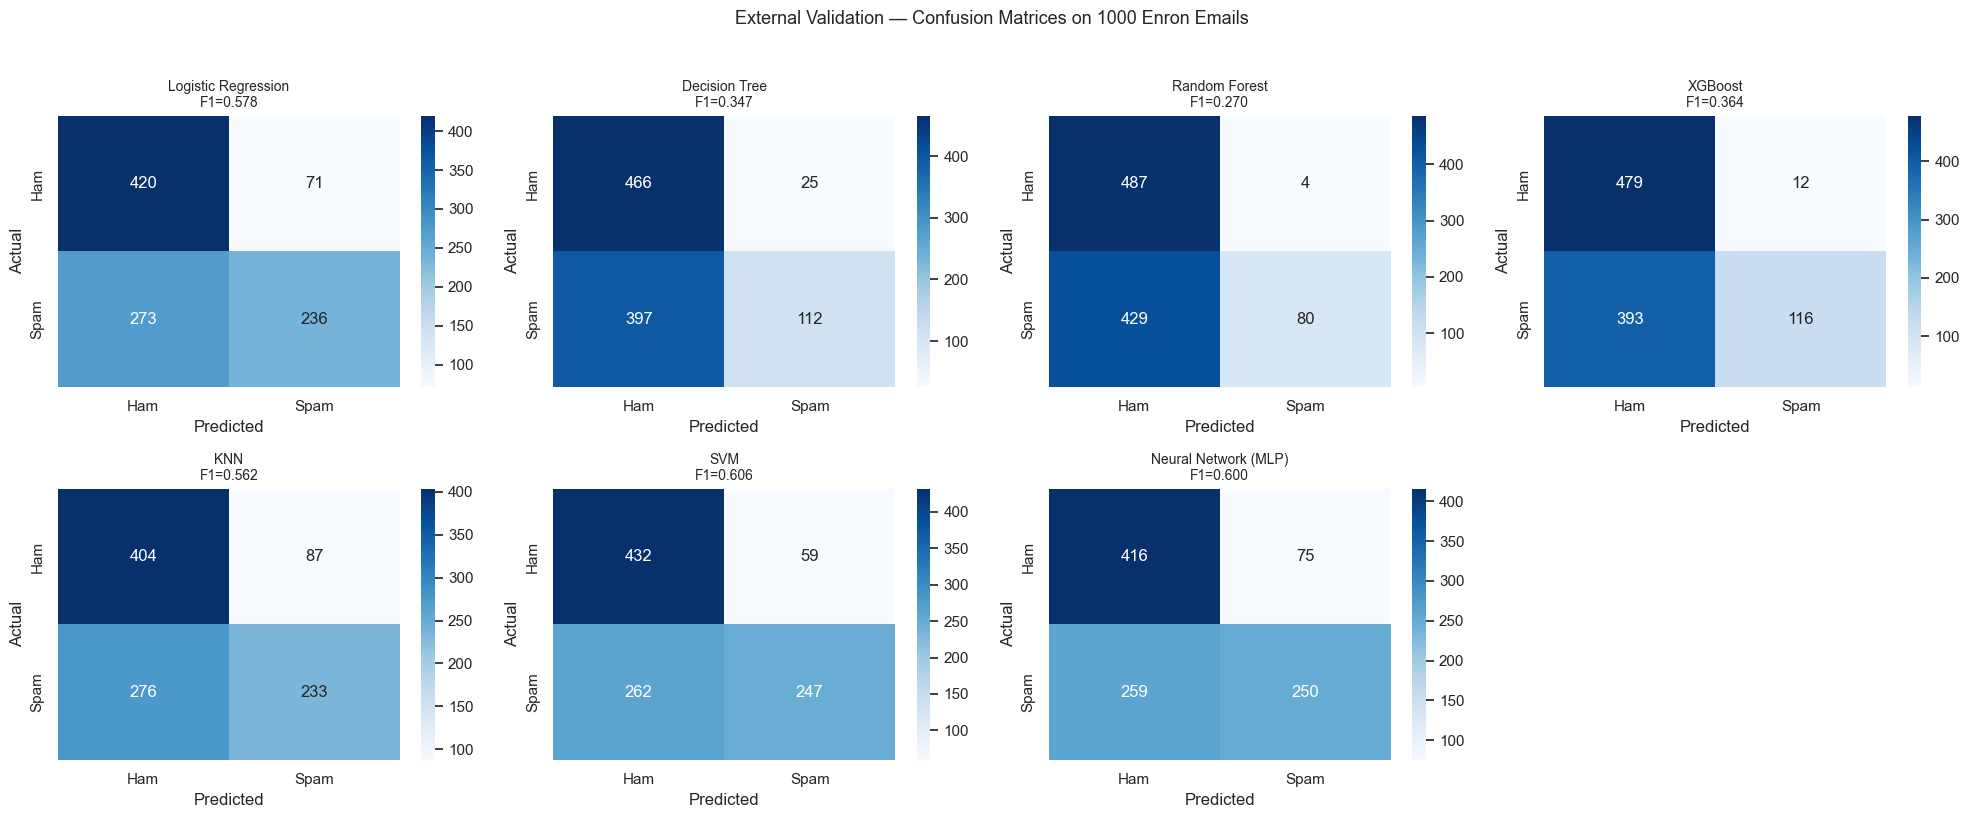


External Validation Results — All Models on Enron Emails:

                      Accuracy  Precision    Recall        F1
Model                                                        
Logistic Regression      0.656   0.768730  0.463654  0.578431
Decision Tree            0.578   0.817518  0.220039  0.346749
Random Forest            0.567   0.952381  0.157171  0.269815
XGBoost                  0.595   0.906250  0.227898  0.364207
KNN                      0.637   0.728125  0.457760  0.562123
SVM                      0.679   0.807190  0.485265  0.606135
Neural Network (MLP)     0.666   0.769231  0.491159  0.599520


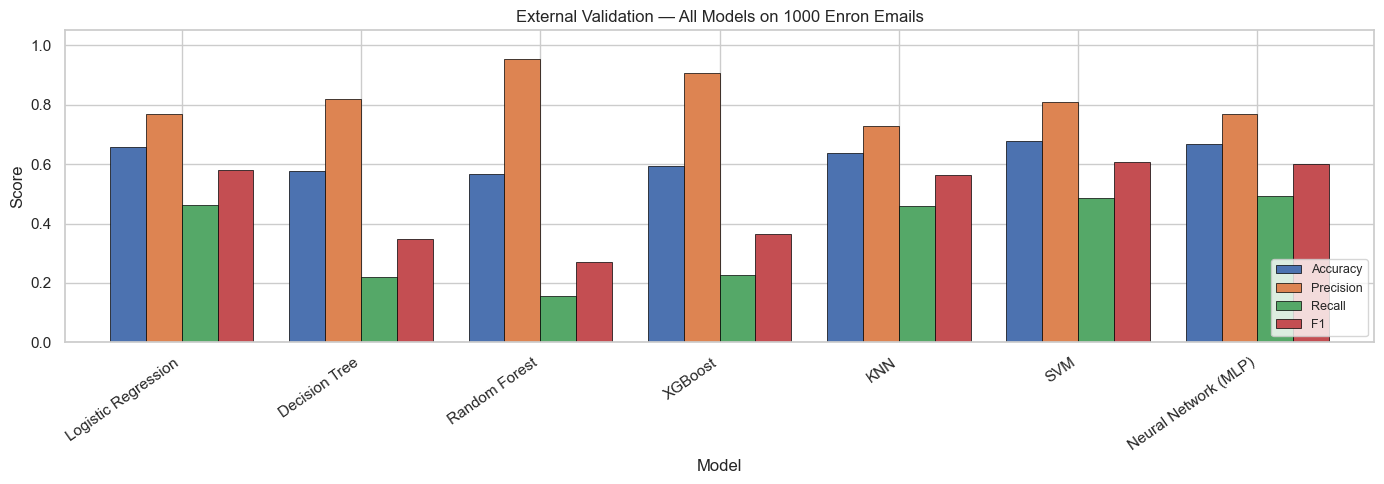

In [34]:
np.random.seed(42)
sample_size = 1000
enron_sample = enron_df.sample(n=sample_size, random_state=42).copy()
enron_sample['full_text'] = (enron_sample['Subject'].fillna('')
                             + ' '
                             + enron_sample['Message'].fillna(''))

print(f"Extracting Spambase features from {sample_size} Enron emails...")
feature_rows = enron_sample['full_text'].apply(extract_spambase_features)
enron_features = pd.DataFrame(feature_rows.tolist(), columns=X_train.columns)

enron_features_scaled = pd.DataFrame(
    scaler.transform(enron_features), columns=X_train.columns
)

sample_counts = enron_sample['label'].value_counts().sort_index()
sample_pcts = enron_sample['label'].value_counts(normalize=True).sort_index() * 100
print(f"\nEnron Sample Target Distribution:")
print(f"  Ham  (0): {sample_counts[0]:>4d}  ({sample_pcts[0]:.1f}%)")
print(f"  Spam (1): {sample_counts[1]:>4d}  ({sample_pcts[1]:.1f}%)")

y_enron = enron_sample['label'].values
enron_results = []

n_models = len(fitted_models)
fig, axes = plt.subplots(2, (n_models + 1) // 2, figsize=(5 * ((n_models + 1) // 2), 8))
axes = axes.ravel()

for i, (name, model) in enumerate(fitted_models.items()):
    X_enron = enron_features_scaled if name in scaled_model_names else enron_features
    y_pred_enron = model.predict(X_enron)

    acc = accuracy_score(y_enron, y_pred_enron)
    prec = precision_score(y_enron, y_pred_enron)
    rec = recall_score(y_enron, y_pred_enron)
    f1 = f1_score(y_enron, y_pred_enron)
    enron_results.append({
        'Model': name, 'Accuracy': acc,
        'Precision': prec, 'Recall': rec, 'F1': f1
    })

    cm = confusion_matrix(y_enron, y_pred_enron)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
    axes[i].set_title(f'{name}\nF1={f1:.3f}', fontsize=10)
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle(f'External Validation — Confusion Matrices on {sample_size} Enron Emails',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

enron_results_df = pd.DataFrame(enron_results).set_index('Model')
print("\nExternal Validation Results — All Models on Enron Emails:\n")
print(enron_results_df.to_string())

fig, ax = plt.subplots(figsize=(14, 5))
enron_results_df.plot(kind='bar', ax=ax, width=0.8, edgecolor='black', linewidth=0.5)
ax.set_title(f'External Validation — All Models on {sample_size} Enron Emails')
ax.set_ylabel('Score')
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
ax.legend(loc='lower right', fontsize=9)
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.show()

## 8. Hyperparameter Tuning

The models in Section 4 used reasonable default hyperparameters. Here we use **RandomizedSearchCV** to systematically search for better parameter combinations, which can improve generalization — especially on external data like the Enron dataset.

We tune the three models that showed the best generalization on the Enron dataset: **XGBoost**, **SVM**, and **Neural Network (MLP)**.

In [35]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

tuning_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
tuned_results = []
tuned_models = {}

def tune_and_evaluate(name, estimator, param_dist, X_tr, X_te, y_tr, y_te,
                      n_iter=50, is_scaled=False):
    """Run RandomizedSearchCV, refit best model, evaluate on test set."""

    search = RandomizedSearchCV(
        estimator, param_distributions=param_dist,
        n_iter=n_iter, cv=tuning_cv, scoring='f1',
        random_state=42, n_jobs=-1, verbose=0
    )
    search.fit(X_tr, y_tr)

    best = search.best_estimator_
    y_pred = best.predict(X_te)
    y_prob = (best.predict_proba(X_te)[:, 1]
              if hasattr(best, 'predict_proba')
              else best.decision_function(X_te))

    row = {
        'Model': name,
        'Best CV F1': search.best_score_,
        'Test Accuracy':  accuracy_score(y_te, y_pred),
        'Test Precision': precision_score(y_te, y_pred),
        'Test Recall':    recall_score(y_te, y_pred),
        'Test F1':        f1_score(y_te, y_pred),
        'Test ROC-AUC':   roc_auc_score(y_te, y_prob),
    }
    tuned_results.append(row)
    tuned_models[name] = best
    if is_scaled:
        scaled_model_names.add(name + ' (tuned)')

    print(f"{'=' * 60}")
    print(f"  {name} — Tuned")
    print(f"{'=' * 60}")
    print(f"\n  Best parameters:")
    for k, v in search.best_params_.items():
        print(f"    {k}: {v}")
    print(f"\n  Best CV F1: {search.best_score_:.4f}")
    print(f"\n  Test Set Results:")
    print(f"    Accuracy:  {row['Test Accuracy']:.4f}")
    print(f"    Precision: {row['Test Precision']:.4f}")
    print(f"    Recall:    {row['Test Recall']:.4f}")
    print(f"    F1:        {row['Test F1']:.4f}")
    print(f"    ROC-AUC:   {row['Test ROC-AUC']:.4f}")

    fig, ax = plt.subplots(figsize=(5, 4))
    cm = confusion_matrix(y_te, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Non-Spam', 'Spam'], yticklabels=['Non-Spam', 'Spam'])
    ax.set_title(f'{name} (Tuned) — Confusion Matrix')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
    plt.tight_layout()
    plt.show()

    return best

### 8.1 XGBoost Tuning

  XGBoost — Tuned

  Best parameters:
    colsample_bytree: 0.7001005442063456
    gamma: 0.0388347344294232
    learning_rate: 0.0979469992552346
    max_depth: 6
    min_child_weight: 1
    n_estimators: 313
    subsample: 0.9079974212394444

  Best CV F1: 0.9455

  Test Set Results:
    Accuracy:  0.9468
    Precision: 0.9385
    Recall:    0.9256
    F1:        0.9320
    ROC-AUC:   0.9866


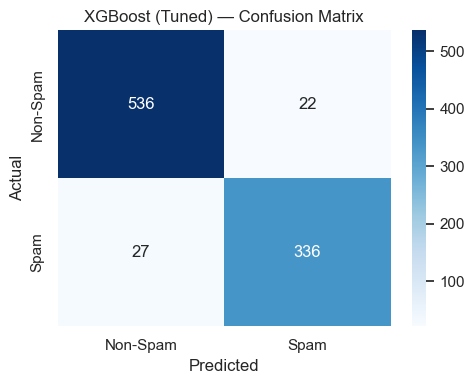

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,np.float64(0.7001005442063456)
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = x

In [36]:
xgb_params = {
    'n_estimators': randint(50, 500),
    'max_depth': randint(2, 12),
    'learning_rate': uniform(0.01, 0.29),
    'min_child_weight': randint(1, 10),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'gamma': uniform(0, 1),
}

tune_and_evaluate(
    'XGBoost', XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0),
    xgb_params, X_train, X_test, y_train, y_test, n_iter=60
)

### 8.2 Neural Network (MLP) Tuning

  Neural Network (MLP) — Tuned

  Best parameters:
    activation: tanh
    alpha: 0.009817820827209606
    batch_size: 128
    hidden_layer_sizes: (128, 64)
    learning_rate_init: 0.0030178229582536417

  Best CV F1: 0.9261

  Test Set Results:
    Accuracy:  0.9392
    Precision: 0.9300
    Recall:    0.9146
    F1:        0.9222
    ROC-AUC:   0.9829


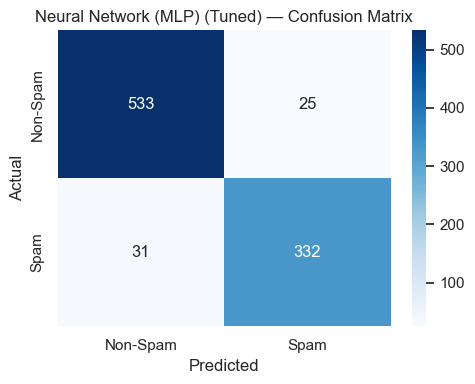

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(128, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'tanh'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",np.float64(0....7820827209606)
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",128
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",np.float64(0....8229582536417)
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


In [37]:
mlp_params = {
    'hidden_layer_sizes': [(64,), (128,), (64, 32), (128, 64), (128, 64, 32), (256, 128)],
    'alpha': uniform(0.0001, 0.01),
    'learning_rate_init': uniform(0.0005, 0.01),
    'batch_size': [16, 32, 64, 128],
    'activation': ['relu', 'tanh'],
}

tune_and_evaluate(
    'Neural Network (MLP)',
    MLPClassifier(max_iter=500, random_state=42, early_stopping=True, validation_fraction=0.15),
    mlp_params, X_train_scaled, X_test_scaled, y_train, y_test,
    n_iter=50, is_scaled=True
)

### 8.3 SVM Tuning

  SVM — Tuned

  Best parameters:
    C: 46.43294328968971
    gamma: 0.01
    kernel: rbf

  Best CV F1: 0.9201

  Test Set Results:
    Accuracy:  0.9218
    Precision: 0.9145
    Recall:    0.8843
    F1:        0.8992
    ROC-AUC:   0.9678


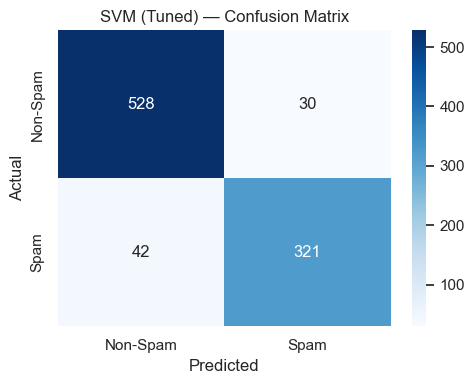

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",np.float64(46.43294328968971)
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.01
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [38]:
svm_params = {
    'C': uniform(0.1, 50),
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
    'kernel': ['rbf', 'poly'],
}

tune_and_evaluate(
    'SVM', SVC(probability=True, random_state=42),
    svm_params, X_train_scaled, X_test_scaled, y_train, y_test,
    n_iter=40, is_scaled=True
)

### 8.4 Comparison: Default vs. Tuned Models

Default vs. Tuned — Test Set Metrics:

  XGBoost:
    Test Accuracy     Default: 0.9457  →  Tuned: 0.9468  (▲ 0.0011)
    Test Precision    Default: 0.9359  →  Tuned: 0.9385  (▲ 0.0026)
    Test Recall       Default: 0.9256  →  Tuned: 0.9256  (= 0.0000)
    Test F1           Default: 0.9307  →  Tuned: 0.9320  (▲ 0.0013)
    Test ROC-AUC      Default: 0.9874  →  Tuned: 0.9866  (▼ 0.0008)

  Neural Network (MLP):
    Test Accuracy     Default: 0.9392  →  Tuned: 0.9392  (= 0.0000)
    Test Precision    Default: 0.9324  →  Tuned: 0.9300  (▼ 0.0024)
    Test Recall       Default: 0.9118  →  Tuned: 0.9146  (▲ 0.0028)
    Test F1           Default: 0.9220  →  Tuned: 0.9222  (▲ 0.0002)
    Test ROC-AUC      Default: 0.9827  →  Tuned: 0.9829  (▲ 0.0003)

  SVM:
    Test Accuracy     Default: 0.9273  →  Tuned: 0.9218  (▼ 0.0054)
    Test Precision    Default: 0.9277  →  Tuned: 0.9145  (▼ 0.0132)
    Test Recall       Default: 0.8843  →  Tuned: 0.8843  (= 0.0000)
    Test F1           Default: 0.

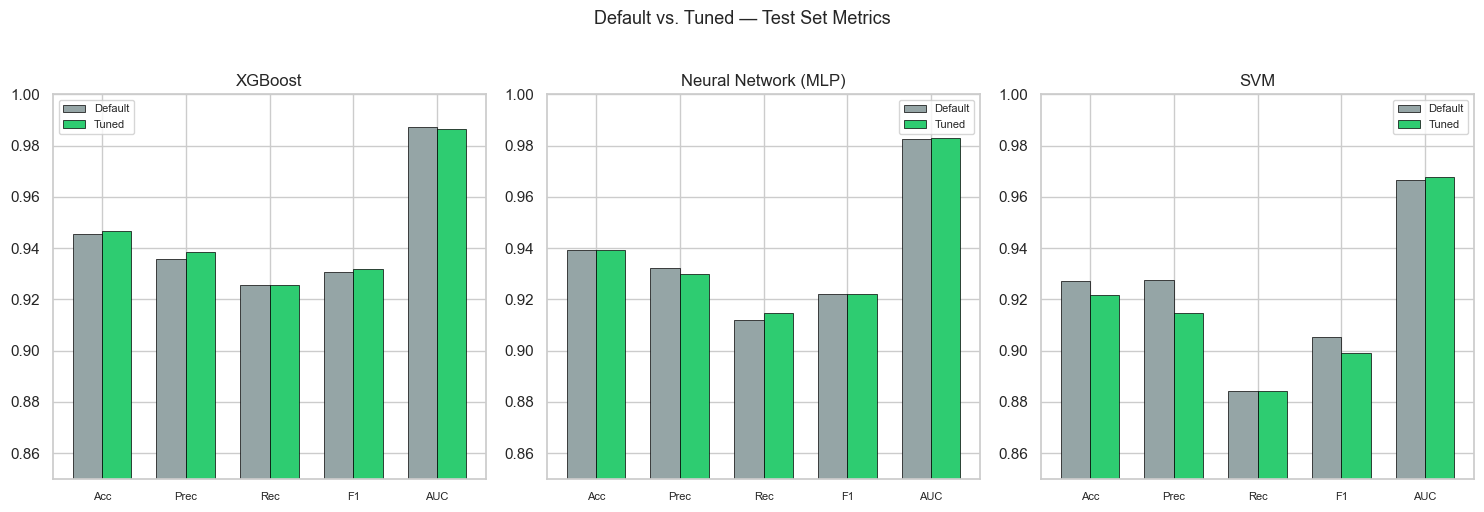

In [39]:
tuned_df = pd.DataFrame(tuned_results)

tuned_names = tuned_df['Model'].tolist()
default_subset = results_df[results_df['Model'].isin(tuned_names)][
    ['Model', 'Test Accuracy', 'Test Precision', 'Test Recall', 'Test F1', 'Test ROC-AUC']
].copy()
default_subset['Version'] = 'Default'

tuned_compare = tuned_df[
    ['Model', 'Test Accuracy', 'Test Precision', 'Test Recall', 'Test F1', 'Test ROC-AUC']
].copy()
tuned_compare['Version'] = 'Tuned'

compare_df = pd.concat([default_subset, tuned_compare], ignore_index=True)

print("Default vs. Tuned — Test Set Metrics:\n")
for model_name in tuned_names:
    d = default_subset[default_subset['Model'] == model_name].iloc[0]
    t = tuned_compare[tuned_compare['Model'] == model_name].iloc[0]
    print(f"  {model_name}:")
    for metric in ['Test Accuracy', 'Test Precision', 'Test Recall', 'Test F1', 'Test ROC-AUC']:
        diff = t[metric] - d[metric]
        arrow = '▲' if diff > 0 else ('▼' if diff < 0 else '=')
        print(f"    {metric:<16s}  Default: {d[metric]:.4f}  →  Tuned: {t[metric]:.4f}  ({arrow} {abs(diff):.4f})")
    print()

fig, axes = plt.subplots(1, len(tuned_names), figsize=(5 * len(tuned_names), 5))
if len(tuned_names) == 1:
    axes = [axes]
metrics = ['Test Accuracy', 'Test Precision', 'Test Recall', 'Test F1', 'Test ROC-AUC']

for ax, model_name in zip(axes, tuned_names):
    d_vals = default_subset[default_subset['Model'] == model_name][metrics].values[0]
    t_vals = tuned_compare[tuned_compare['Model'] == model_name][metrics].values[0]

    x = np.arange(len(metrics))
    width = 0.35
    ax.bar(x - width/2, d_vals, width, label='Default', color='#95a5a6', edgecolor='black', linewidth=0.5)
    ax.bar(x + width/2, t_vals, width, label='Tuned', color='#2ecc71', edgecolor='black', linewidth=0.5)
    ax.set_title(model_name)
    ax.set_xticks(x)
    ax.set_xticklabels(['Acc', 'Prec', 'Rec', 'F1', 'AUC'], fontsize=8)
    ax.set_ylim([0.85, 1.0])
    ax.legend(fontsize=8)

plt.suptitle('Default vs. Tuned — Test Set Metrics', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 8.5 Tuned Models on Enron Dataset

Re-evaluate the tuned models on the same Enron sample to see if hyperparameter tuning improved generalization to external data.

Enron Validation — Default vs. Tuned:

  XGBoost:
    Accuracy      Default: 0.5950  →  Tuned: 0.5720  (▼ 0.0230)
    Precision     Default: 0.9062  →  Tuned: 0.9551  (▲ 0.0488)
    Recall        Default: 0.2279  →  Tuned: 0.1670  (▼ 0.0609)
    F1            Default: 0.3642  →  Tuned: 0.2843  (▼ 0.0799)

  Neural Network (MLP):
    Accuracy      Default: 0.6660  →  Tuned: 0.5740  (▼ 0.0920)
    Precision     Default: 0.7692  →  Tuned: 0.5492  (▼ 0.2200)
    Recall        Default: 0.4912  →  Tuned: 0.9096  (▲ 0.4185)
    F1            Default: 0.5995  →  Tuned: 0.6849  (▲ 0.0854)

  SVM:
    Accuracy      Default: 0.6790  →  Tuned: 0.6620  (▼ 0.0170)
    Precision     Default: 0.8072  →  Tuned: 0.7767  (▼ 0.0305)
    Recall        Default: 0.4853  →  Tuned: 0.4715  (▼ 0.0138)
    F1            Default: 0.6061  →  Tuned: 0.5868  (▼ 0.0193)



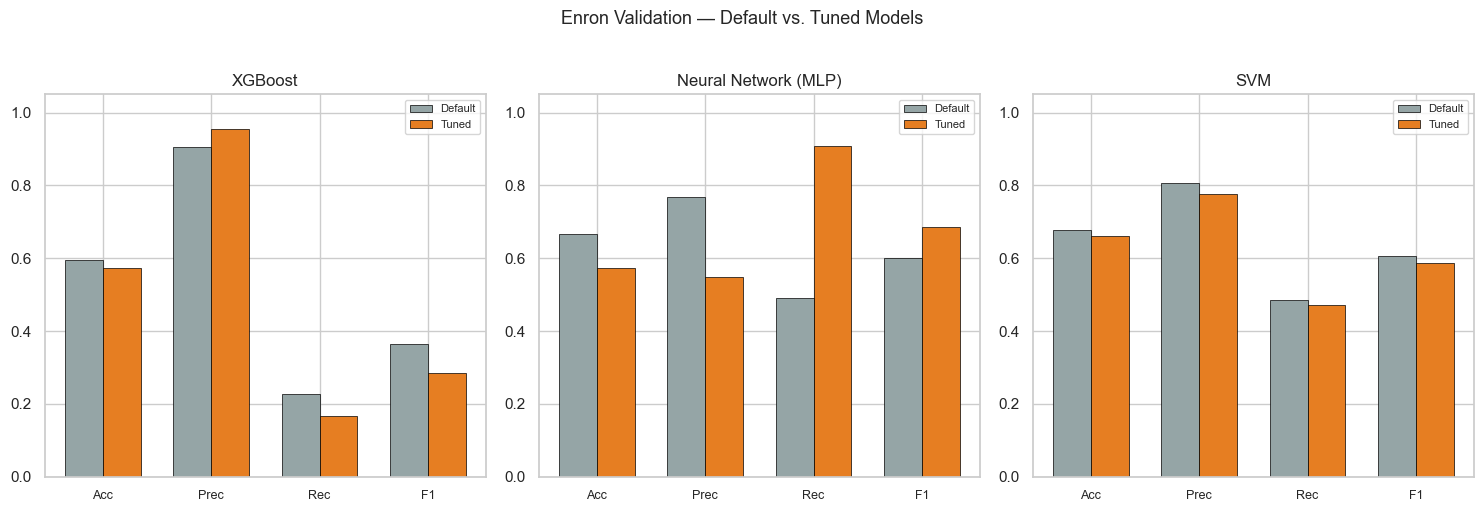

In [40]:
tuned_enron_results = []
tuned_scaled = {'SVM', 'Logistic Regression'}

for name, model in tuned_models.items():
    X_enron_input = enron_features_scaled if name in tuned_scaled else enron_features
    y_pred_e = model.predict(X_enron_input)

    tuned_enron_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_enron, y_pred_e),
        'Precision': precision_score(y_enron, y_pred_e),
        'Recall': recall_score(y_enron, y_pred_e),
        'F1': f1_score(y_enron, y_pred_e),
    })

tuned_enron_df = pd.DataFrame(tuned_enron_results).set_index('Model')

default_enron_subset = enron_results_df.loc[
    enron_results_df.index.isin(tuned_enron_df.index)
]

print("Enron Validation — Default vs. Tuned:\n")
for model_name in tuned_enron_df.index:
    d = default_enron_subset.loc[model_name]
    t = tuned_enron_df.loc[model_name]
    print(f"  {model_name}:")
    for metric in ['Accuracy', 'Precision', 'Recall', 'F1']:
        diff = t[metric] - d[metric]
        arrow = '▲' if diff > 0 else ('▼' if diff < 0 else '=')
        print(f"    {metric:<12s}  Default: {d[metric]:.4f}  →  Tuned: {t[metric]:.4f}  ({arrow} {abs(diff):.4f})")
    print()

fig, axes = plt.subplots(1, len(tuned_models), figsize=(5 * len(tuned_models), 5))
if len(tuned_models) == 1:
    axes = [axes]

for ax, model_name in zip(axes, tuned_enron_df.index):
    d_vals = default_enron_subset.loc[model_name, ['Accuracy', 'Precision', 'Recall', 'F1']].values
    t_vals = tuned_enron_df.loc[model_name, ['Accuracy', 'Precision', 'Recall', 'F1']].values

    x = np.arange(4)
    width = 0.35
    ax.bar(x - width/2, d_vals, width, label='Default', color='#95a5a6', edgecolor='black', linewidth=0.5)
    ax.bar(x + width/2, t_vals, width, label='Tuned', color='#e67e22', edgecolor='black', linewidth=0.5)
    ax.set_title(model_name)
    ax.set_xticks(x)
    ax.set_xticklabels(['Acc', 'Prec', 'Rec', 'F1'], fontsize=9)
    ax.set_ylim([0, 1.05])
    ax.legend(fontsize=8)

plt.suptitle('Enron Validation — Default vs. Tuned Models', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 9. Threshold Optimization

All classifiers use a default decision threshold of **0.5**: if P(spam) >= 0.5, predict spam. But in spam filtering, the costs are asymmetric:

- **False Positive** (legitimate email → spam folder): Very costly — user misses important mail
- **False Negative** (spam → inbox): Annoying but less harmful

By adjusting the threshold, we can trade recall for precision. A higher threshold means fewer false positives but more spam slipping through.

### 9.1 Precision-Recall Curves

Visualize the precision-recall trade-off for all models that support probability estimates.

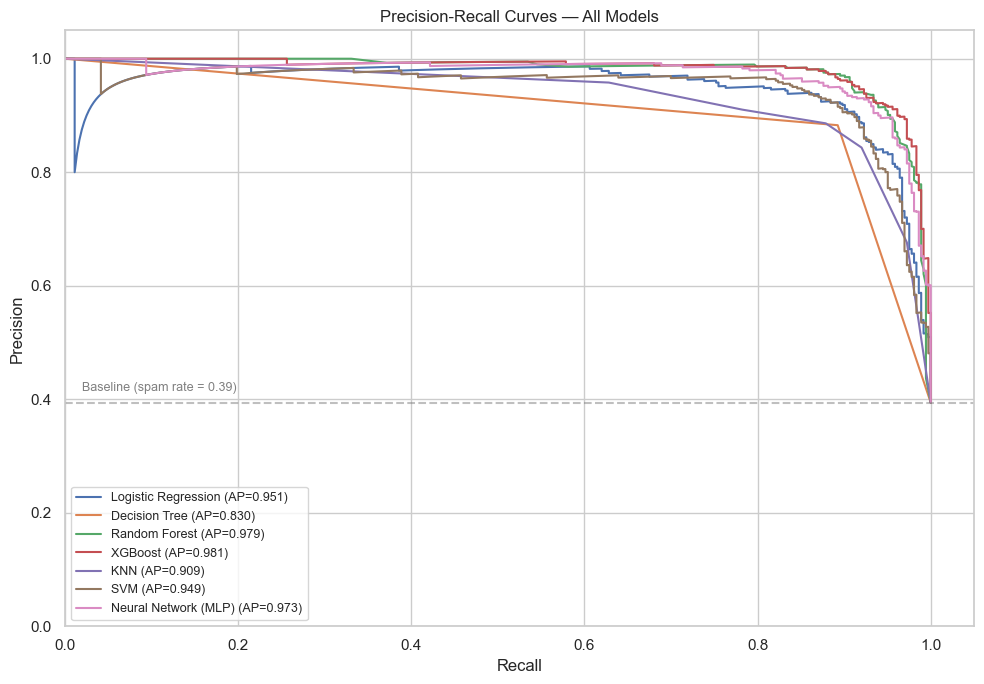

In [41]:
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, ax = plt.subplots(figsize=(10, 7))

for name, model in fitted_models.items():
    X_te = X_test_scaled if name in scaled_model_names else X_test
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_te)[:, 1]
    else:
        y_prob = model.decision_function(X_te)

    prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    ax.plot(rec_curve, prec_curve, label=f'{name} (AP={ap:.3f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves — All Models')
ax.legend(loc='lower left', fontsize=9)
ax.set_xlim([0, 1.05])
ax.set_ylim([0, 1.05])
ax.axhline(y=y_test.mean(), color='gray', linestyle='--', alpha=0.5)
ax.text(0.02, y_test.mean() + 0.02, f'Baseline (spam rate = {y_test.mean():.2f})',
        color='gray', fontsize=9)
plt.tight_layout()
plt.show()

### 9.2 Optimal Threshold Selection

For **XGBoost**, **SVM**, and **Neural Network (MLP)**, find the threshold that maximizes F1 score, and compare it with a threshold optimized for high precision (minimizing false positives).

Threshold Comparison for XGBoost:

  Scenario                        Precision     Recall         F1
  ------------------------------ ---------- ---------- ----------
  Default (0.5)                      0.9359     0.9256     0.9307
  Best F1 (0.28)                     0.9112     0.9614     0.9357
  High Prec (0.69)                   0.9514     0.9174     0.9341

Threshold Comparison for SVM:

  Scenario                        Precision     Recall         F1
  ------------------------------ ---------- ---------- ----------
  Default (0.5)                      0.9251     0.8843     0.9042
  Best F1 (0.32)                     0.9041     0.9091     0.9066
  High Prec (0.74)                   0.9505     0.8457     0.8950

Threshold Comparison for Neural Network (MLP):

  Scenario                        Precision     Recall         F1
  ------------------------------ ---------- ---------- ----------
  Default (0.5)                      0.9324     0.9118     0.9220
  Best F1 (0.42)          

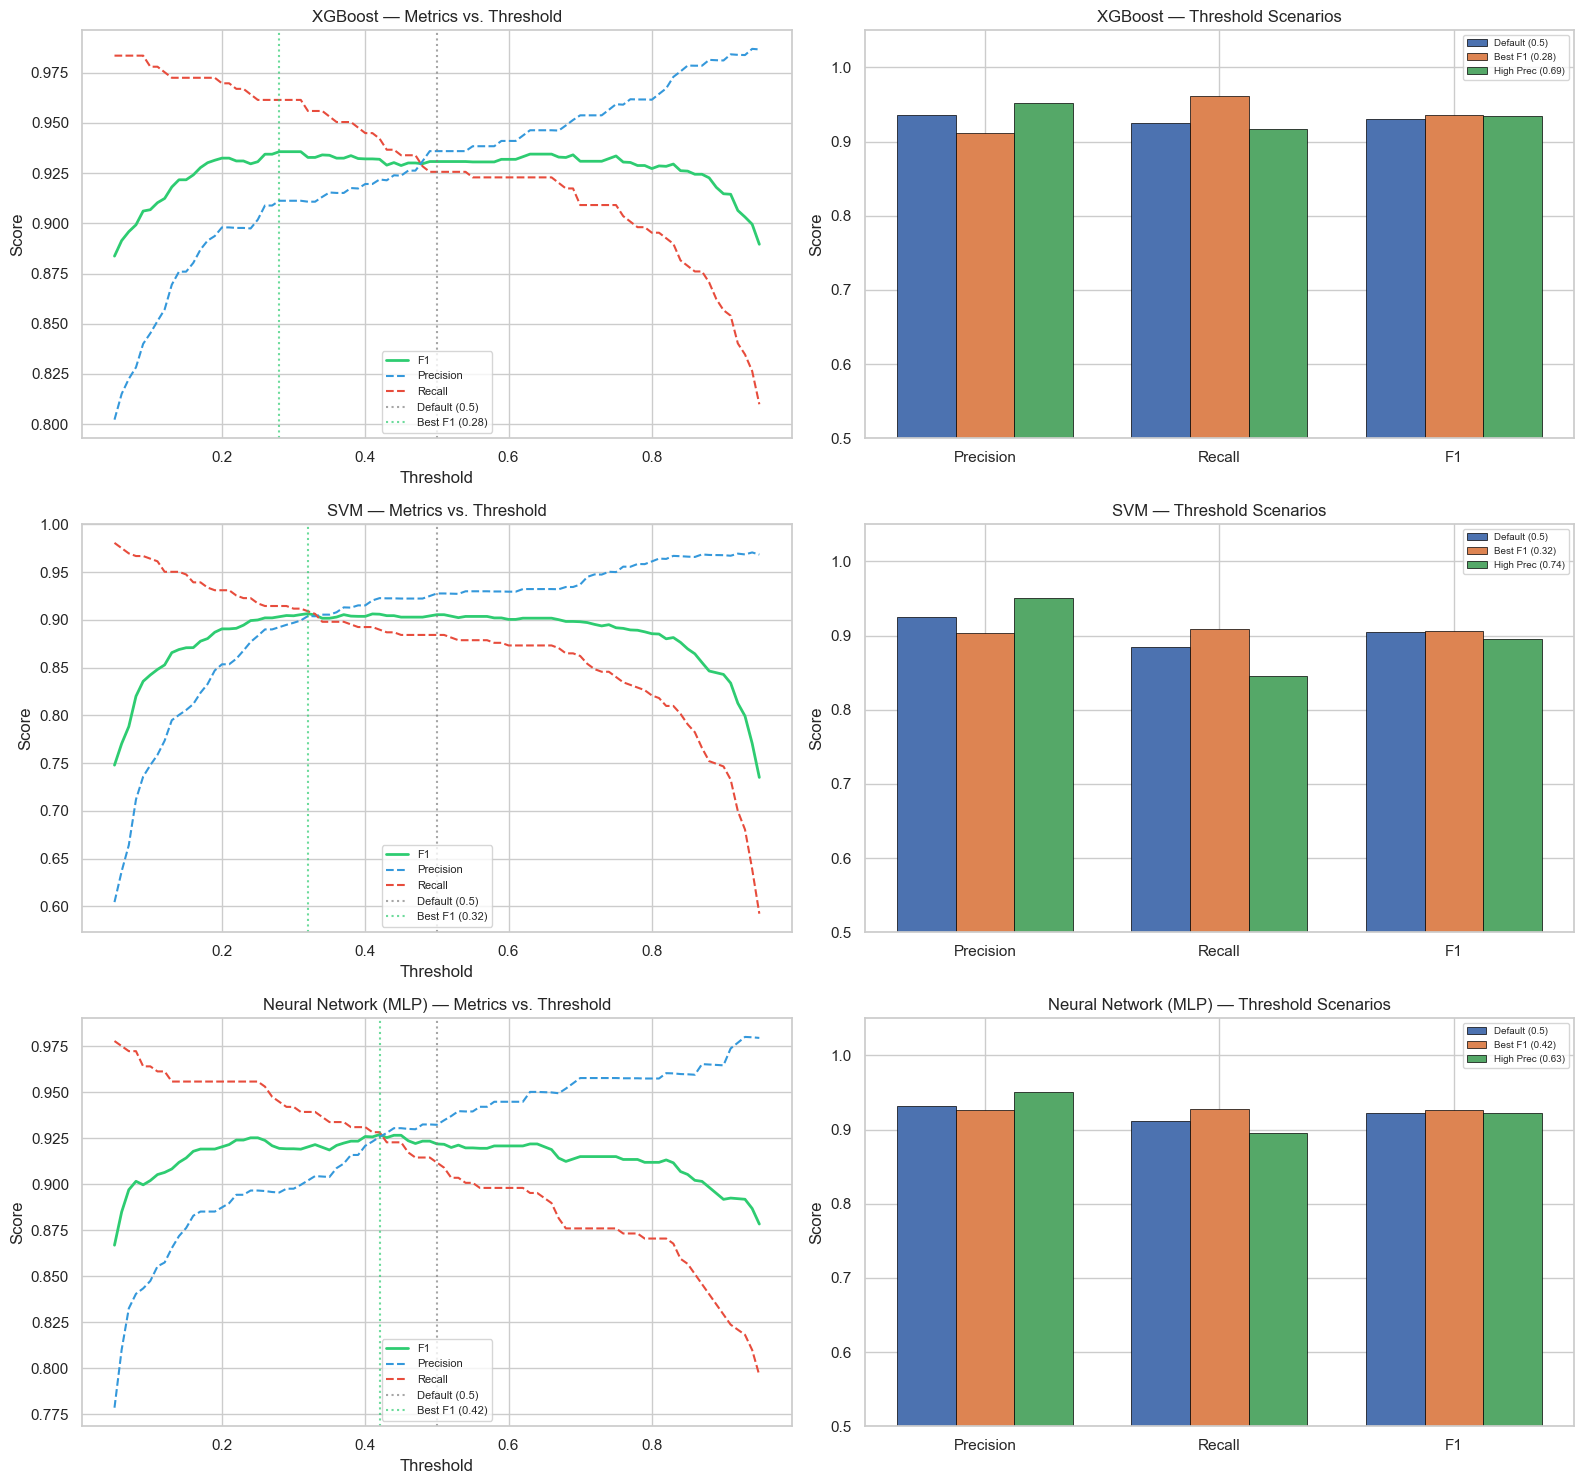

In [42]:
focus_models = ['XGBoost', 'SVM', 'Neural Network (MLP)']
thresholds = np.arange(0.05, 0.96, 0.01)

fig, axes = plt.subplots(len(focus_models), 2, figsize=(16, 5 * len(focus_models)))

for row, model_name in enumerate(focus_models):
    model = fitted_models[model_name]
    X_te = X_test_scaled if model_name in scaled_model_names else X_test

    if hasattr(model, 'predict_proba'):
        y_scores = model.predict_proba(X_te)[:, 1]
    else:
        y_scores = model.decision_function(X_te)

    f1s = [f1_score(y_test, (y_scores >= t).astype(int)) for t in thresholds]
    precs = [precision_score(y_test, (y_scores >= t).astype(int), zero_division=0) for t in thresholds]
    recs = [recall_score(y_test, (y_scores >= t).astype(int)) for t in thresholds]

    best_f1_thresh = thresholds[np.argmax(f1s)]

    hp_mask = [i for i, p in enumerate(precs) if p >= 0.95]
    hp_thresh = thresholds[max(hp_mask, key=lambda i: recs[i])] if hp_mask else 0.9

    axes[row, 0].plot(thresholds, f1s, label='F1', color='#2ecc71', linewidth=2)
    axes[row, 0].plot(thresholds, precs, label='Precision', color='#3498db', linewidth=1.5, linestyle='--')
    axes[row, 0].plot(thresholds, recs, label='Recall', color='#e74c3c', linewidth=1.5, linestyle='--')
    axes[row, 0].axvline(x=0.5, color='gray', linestyle=':', alpha=0.7, label='Default (0.5)')
    axes[row, 0].axvline(x=best_f1_thresh, color='#2ecc71', linestyle=':', alpha=0.7,
                          label=f'Best F1 ({best_f1_thresh:.2f})')
    axes[row, 0].set_xlabel('Threshold')
    axes[row, 0].set_ylabel('Score')
    axes[row, 0].set_title(f'{model_name} — Metrics vs. Threshold')
    axes[row, 0].legend(fontsize=8)

    scenarios = {
        'Default (0.5)': 0.5,
        f'Best F1 ({best_f1_thresh:.2f})': best_f1_thresh,
        f'High Prec ({hp_thresh:.2f})': hp_thresh,
    }
    x = np.arange(3)
    width = 0.25
    for j, (sname, t) in enumerate(scenarios.items()):
        yp = (y_scores >= t).astype(int)
        vals = [precision_score(y_test, yp, zero_division=0), recall_score(y_test, yp), f1_score(y_test, yp)]
        axes[row, 1].bar(x + j * width, vals, width, label=sname, edgecolor='black', linewidth=0.5)
    axes[row, 1].set_xticks(x + width)
    axes[row, 1].set_xticklabels(['Precision', 'Recall', 'F1'])
    axes[row, 1].set_ylabel('Score')
    axes[row, 1].set_title(f'{model_name} — Threshold Scenarios')
    axes[row, 1].legend(fontsize=7)
    axes[row, 1].set_ylim([0.5, 1.05])

    print(f"Threshold Comparison for {model_name}:\n")
    print(f"  {'Scenario':<30s} {'Precision':>10s} {'Recall':>10s} {'F1':>10s}")
    print(f"  {'-'*30} {'-'*10} {'-'*10} {'-'*10}")
    for sname, t in scenarios.items():
        yp = (y_scores >= t).astype(int)
        print(f"  {sname:<30s} {precision_score(y_test, yp, zero_division=0):>10.4f} {recall_score(y_test, yp):>10.4f} {f1_score(y_test, yp):>10.4f}")
    print()

plt.tight_layout()
plt.show()

### 9.3 Discussion

The threshold analysis shows the fundamental **precision-recall trade-off** in spam filtering:

- **Default threshold (0.5)**: Balanced, but some legitimate emails may be flagged as spam.
- **Best F1 threshold**: Optimizes the harmonic mean of precision and recall — a good general-purpose choice.
- **High precision threshold**: Minimizes false positives at the cost of letting more spam through — the safer option when losing legitimate emails is unacceptable.

In practice, the choice depends on the use case: a personal inbox might prefer high precision (never lose a real email), while a corporate filter might accept more false positives to catch nearly all spam.

## 10. Feature Selection

So far, all 57 features have been used. But some features may be redundant or uninformative. Reducing the feature set can:
- Improve generalization (less overfitting)
- Reduce training time
- Make the model more interpretable

We compare three approaches: **univariate selection (SelectKBest)**, **model-based selection (from XGBoost importances)**, and evaluate how models perform with reduced feature sets.

### 10.1 Feature Ranking

Rank all 57 features using two independent methods and compare their top selections.

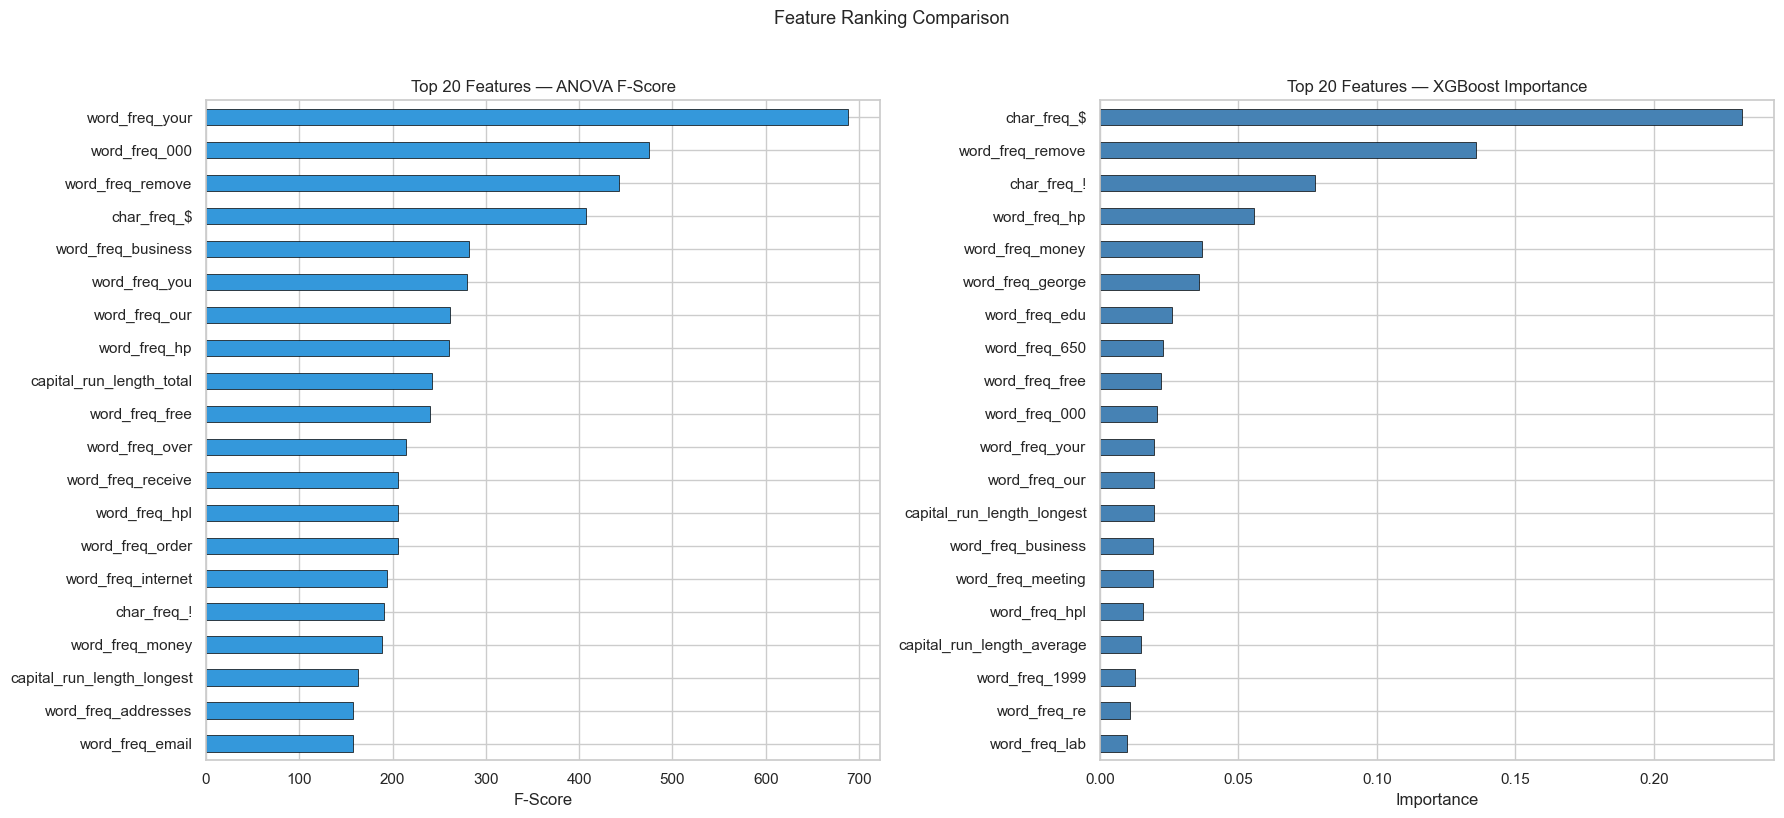

Top 20 overlap between ANOVA and XGBoost: 12 features
  Shared: ['capital_run_length_longest', 'char_freq_!', 'char_freq_$', 'word_freq_000', 'word_freq_business', 'word_freq_free', 'word_freq_hp', 'word_freq_hpl', 'word_freq_money', 'word_freq_our', 'word_freq_remove', 'word_freq_your']
  Only ANOVA:   ['capital_run_length_total', 'word_freq_addresses', 'word_freq_email', 'word_freq_internet', 'word_freq_order', 'word_freq_over', 'word_freq_receive', 'word_freq_you']
  Only XGBoost: ['capital_run_length_average', 'word_freq_1999', 'word_freq_650', 'word_freq_edu', 'word_freq_george', 'word_freq_lab', 'word_freq_meeting', 'word_freq_re']


In [43]:
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif

selector_anova = SelectKBest(f_classif, k='all')
selector_anova.fit(X_train, y_train)
anova_scores = pd.Series(selector_anova.scores_, index=X_train.columns).sort_values(ascending=False)

xgb_importance = pd.Series(
    fitted_models['XGBoost'].feature_importances_, index=X_train.columns
).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

anova_scores.head(20).sort_values().plot(kind='barh', ax=axes[0], color='#3498db', edgecolor='black', linewidth=0.5)
axes[0].set_title('Top 20 Features — ANOVA F-Score')
axes[0].set_xlabel('F-Score')

xgb_importance.head(20).sort_values().plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='black', linewidth=0.5)
axes[1].set_title('Top 20 Features — XGBoost Importance')
axes[1].set_xlabel('Importance')

plt.suptitle('Feature Ranking Comparison', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

anova_top20 = set(anova_scores.head(20).index)
xgb_top20 = set(xgb_importance.head(20).index)
overlap = anova_top20 & xgb_top20

print(f"Top 20 overlap between ANOVA and XGBoost: {len(overlap)} features")
print(f"  Shared: {sorted(overlap)}")
print(f"  Only ANOVA:   {sorted(anova_top20 - xgb_top20)}")
print(f"  Only XGBoost: {sorted(xgb_top20 - anova_top20)}")

### 10.2 Performance vs. Number of Features

Train **XGBoost**, **SVM**, and **Neural Network (MLP)** with increasing numbers of features (ranked by XGBoost importance) to find the minimum feature set that maintains performance.

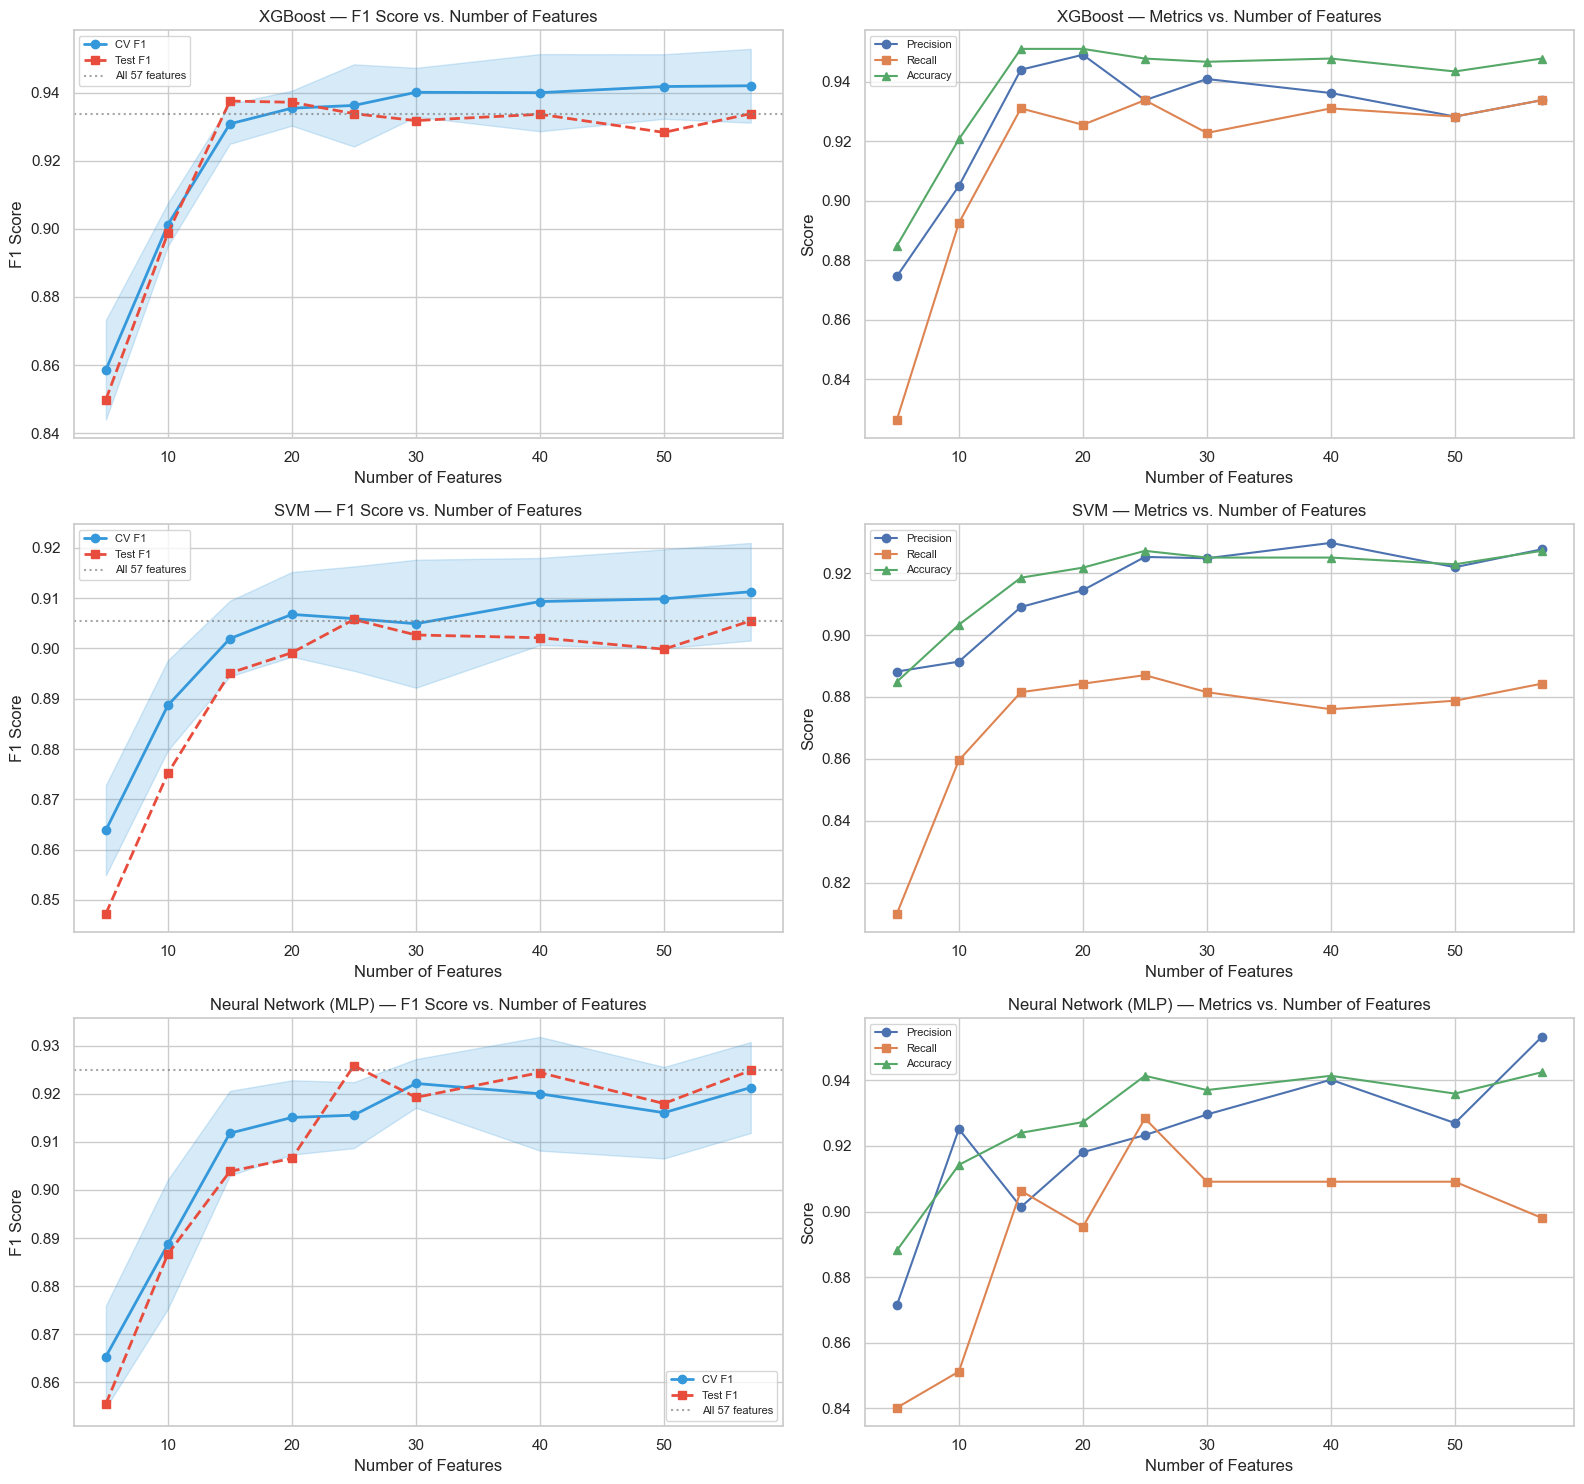


Performance by number of features (XGBoost):

 k  CV F1 (mean)  CV F1 (std)  Test F1  Test Accuracy  Test Precision  Test Recall
 5      0.858582     0.014638 0.849858       0.884908        0.874636     0.826446
10      0.901269     0.006319 0.898752       0.920738        0.905028     0.892562
15      0.930885     0.005856 0.937587       0.951140        0.944134     0.931129
20      0.935498     0.005145 0.937238       0.951140        0.949153     0.925620
25      0.936301     0.012082 0.933884       0.947883        0.933884     0.933884
30      0.940162     0.007187 0.931850       0.946797        0.941011     0.922865
40      0.940052     0.011346 0.933702       0.947883        0.936288     0.931129
50      0.941860     0.009499 0.928375       0.943540        0.928375     0.928375
57      0.942084     0.010845 0.933884       0.947883        0.933884     0.933884

Performance by number of features (SVM):

 k  CV F1 (mean)  CV F1 (std)  Test F1  Test Accuracy  Test Precision  Test Reca

In [44]:
ranked_features = xgb_importance.index.tolist()
feature_counts = [5, 10, 15, 20, 25, 30, 40, 50, 57]

focus_fs_models = {
    'XGBoost': lambda: XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                                      random_state=42, eval_metric='logloss', verbosity=0),
    'SVM': lambda: SVC(kernel='rbf', probability=True, random_state=42),
    'Neural Network (MLP)': lambda: MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=500,
                                                   random_state=42, early_stopping=True,
                                                   validation_fraction=0.15),
}

all_perf_dfs = {}

for model_name, model_factory in focus_fs_models.items():
    needs_scaling = model_name in scaled_model_names
    perf_by_k = []

    for k in feature_counts:
        selected = ranked_features[:k]
        X_tr_k = X_train[selected]
        X_te_k = X_test[selected]

        if needs_scaling:
            sc = StandardScaler()
            X_tr_k = pd.DataFrame(sc.fit_transform(X_tr_k), columns=selected, index=X_tr_k.index)
            X_te_k = pd.DataFrame(sc.transform(X_te_k), columns=selected, index=X_te_k.index)

        model_k = model_factory()
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        cv_f1 = cross_validate(model_k, X_tr_k, y_train, cv=skf, scoring='f1')['test_score']

        model_k = model_factory()
        model_k.fit(X_tr_k, y_train)
        y_pred_k = model_k.predict(X_te_k)

        perf_by_k.append({
            'k': k,
            'CV F1 (mean)': cv_f1.mean(),
            'CV F1 (std)': cv_f1.std(),
            'Test F1': f1_score(y_test, y_pred_k),
            'Test Accuracy': accuracy_score(y_test, y_pred_k),
            'Test Precision': precision_score(y_test, y_pred_k),
            'Test Recall': recall_score(y_test, y_pred_k),
        })

    perf_k_df = pd.DataFrame(perf_by_k)
    all_perf_dfs[model_name] = perf_k_df

fig, axes = plt.subplots(len(focus_fs_models), 2, figsize=(16, 5 * len(focus_fs_models)))

for row, (model_name, perf_k_df) in enumerate(all_perf_dfs.items()):
    axes[row, 0].plot(perf_k_df['k'], perf_k_df['CV F1 (mean)'], 'o-', color='#3498db', label='CV F1', linewidth=2)
    axes[row, 0].fill_between(perf_k_df['k'],
                               perf_k_df['CV F1 (mean)'] - perf_k_df['CV F1 (std)'],
                               perf_k_df['CV F1 (mean)'] + perf_k_df['CV F1 (std)'],
                               alpha=0.2, color='#3498db')
    axes[row, 0].plot(perf_k_df['k'], perf_k_df['Test F1'], 's--', color='#e74c3c', label='Test F1', linewidth=2)
    full_f1 = perf_k_df[perf_k_df['k'] == 57]['Test F1'].values[0]
    axes[row, 0].axhline(y=full_f1, color='gray', linestyle=':', alpha=0.7, label='All 57 features')
    axes[row, 0].set_xlabel('Number of Features')
    axes[row, 0].set_ylabel('F1 Score')
    axes[row, 0].set_title(f'{model_name} — F1 Score vs. Number of Features')
    axes[row, 0].legend(fontsize=8)

    axes[row, 1].plot(perf_k_df['k'], perf_k_df['Test Precision'], 'o-', label='Precision', linewidth=1.5)
    axes[row, 1].plot(perf_k_df['k'], perf_k_df['Test Recall'], 's-', label='Recall', linewidth=1.5)
    axes[row, 1].plot(perf_k_df['k'], perf_k_df['Test Accuracy'], '^-', label='Accuracy', linewidth=1.5)
    axes[row, 1].set_xlabel('Number of Features')
    axes[row, 1].set_ylabel('Score')
    axes[row, 1].set_title(f'{model_name} — Metrics vs. Number of Features')
    axes[row, 1].legend(fontsize=8)

plt.tight_layout()
plt.show()

for model_name, perf_k_df in all_perf_dfs.items():
    print(f"\nPerformance by number of features ({model_name}):\n")
    print(perf_k_df.to_string(index=False))

### 10.3 Reduced Model Comparison

For each of the three focus models (XGBoost, SVM, MLP), determine the individual **optimal number of features** using the elbow method (99% of full-model F1). Then compare all models with their respective reduced feature sets against the full 57-feature baseline.

XGBoost:
  Full F1 (57 feat): 0.9339
  99% threshold:     0.9245
  Optimal k:         15 features (F1 = 0.9376)
  Selected features: ['char_freq_$', 'word_freq_remove', 'char_freq_!', 'word_freq_hp', 'word_freq_money', 'word_freq_george', 'word_freq_edu', 'word_freq_650', 'word_freq_free', 'word_freq_000', 'word_freq_your', 'word_freq_our', 'capital_run_length_longest', 'word_freq_business', 'word_freq_meeting']

SVM:
  Full F1 (57 feat): 0.9055
  99% threshold:     0.8964
  Optimal k:         20 features (F1 = 0.8992)
  Selected features: ['char_freq_$', 'word_freq_remove', 'char_freq_!', 'word_freq_hp', 'word_freq_money', 'word_freq_george', 'word_freq_edu', 'word_freq_650', 'word_freq_free', 'word_freq_000', 'word_freq_your', 'word_freq_our', 'capital_run_length_longest', 'word_freq_business', 'word_freq_meeting', 'word_freq_hpl', 'capital_run_length_average', 'word_freq_1999', 'word_freq_re', 'word_freq_lab']

Neural Network (MLP):
  Full F1 (57 feat): 0.9248
  99% threshold:     0

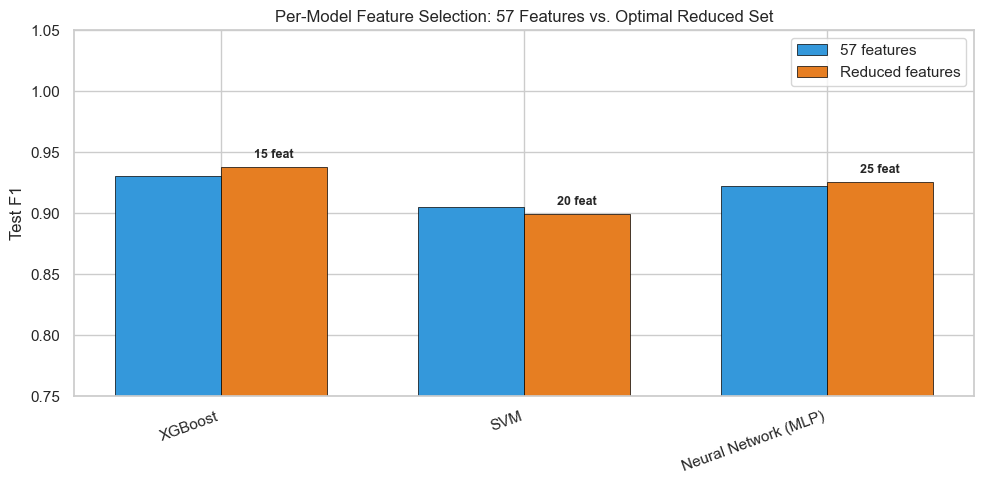

In [45]:
focus_names = ['XGBoost', 'SVM', 'Neural Network (MLP)']

optimal_ks = {}
for model_name in focus_names:
    pk = all_perf_dfs[model_name]
    full_f1 = pk[pk['k'] == 57]['Test F1'].values[0]
    thresh = full_f1 * 0.99
    row = pk[pk['Test F1'] >= thresh].iloc[0]
    optimal_ks[model_name] = int(row['k'])
    print(f"{model_name}:")
    print(f"  Full F1 (57 feat): {full_f1:.4f}")
    print(f"  99% threshold:     {thresh:.4f}")
    print(f"  Optimal k:         {optimal_ks[model_name]} features (F1 = {row['Test F1']:.4f})")
    print(f"  Selected features: {ranked_features[:optimal_ks[model_name]]}")
    print()

reduced_fitted = {}

reduced_results = []

for model_name in focus_names:
    k = optimal_ks[model_name]
    sel_feats = ranked_features[:k]
    needs_scaling = model_name in scaled_model_names

    X_tr_r = X_train[sel_feats]
    X_te_r = X_test[sel_feats]

    if needs_scaling:
        sc = StandardScaler()
        X_tr_r = pd.DataFrame(sc.fit_transform(X_tr_r), columns=sel_feats, index=X_tr_r.index)
        X_te_r = pd.DataFrame(sc.transform(X_te_r), columns=sel_feats, index=X_te_r.index)

    if model_name == 'XGBoost':
        mdl = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                            random_state=42, eval_metric='logloss', verbosity=0)
    elif model_name == 'SVM':
        mdl = SVC(kernel='rbf', probability=True, random_state=42)
    else:
        mdl = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=500,
                            random_state=42, early_stopping=True, validation_fraction=0.15)

    mdl.fit(X_tr_r, y_train)
    y_pred = mdl.predict(X_te_r)

    reduced_fitted[model_name] = {
        'model': mdl,
        'k': k,
        'features': sel_feats,
        'scaler': sc if needs_scaling else None,
    }

    full_f1_val = results_df[results_df['Model'] == model_name]['Test F1'].values[0]
    red_f1_val = f1_score(y_test, y_pred)
    reduced_results.append({
        'Model': model_name,
        'Optimal k': k,
        'Test F1 (57 feat)': full_f1_val,
        'Test F1 (reduced)': red_f1_val,
        'Difference': red_f1_val - full_f1_val,
    })

reduced_df = pd.DataFrame(reduced_results).set_index('Model')

print("Reduced Model Comparison (per-model optimal k):\n")
print(reduced_df.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(reduced_df))
width = 0.35
ax.bar(x - width/2, reduced_df['Test F1 (57 feat)'], width,
       label='57 features', color='#3498db', edgecolor='black', linewidth=0.5)
bars = ax.bar(x + width/2, reduced_df['Test F1 (reduced)'], width,
              label='Reduced features', color='#e67e22', edgecolor='black', linewidth=0.5)

labels = [f"{int(reduced_df.loc[m, 'Optimal k'])} feat" for m in reduced_df.index]
for bar, lbl in zip(bars, labels):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, lbl,
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(reduced_df.index, rotation=20, ha='right')
ax.set_ylabel('Test F1')
ax.set_title('Per-Model Feature Selection: 57 Features vs. Optimal Reduced Set')
ax.legend()
ax.set_ylim([0.75, 1.05])
plt.tight_layout()
plt.show()

### 10.4 Reduced Models on Enron Dataset

Re-evaluate the **reduced-feature** versions of XGBoost, SVM, and Neural Network (MLP) on the Enron sample. Each model uses its own individually optimized feature set (determined by the elbow method in 10.3).

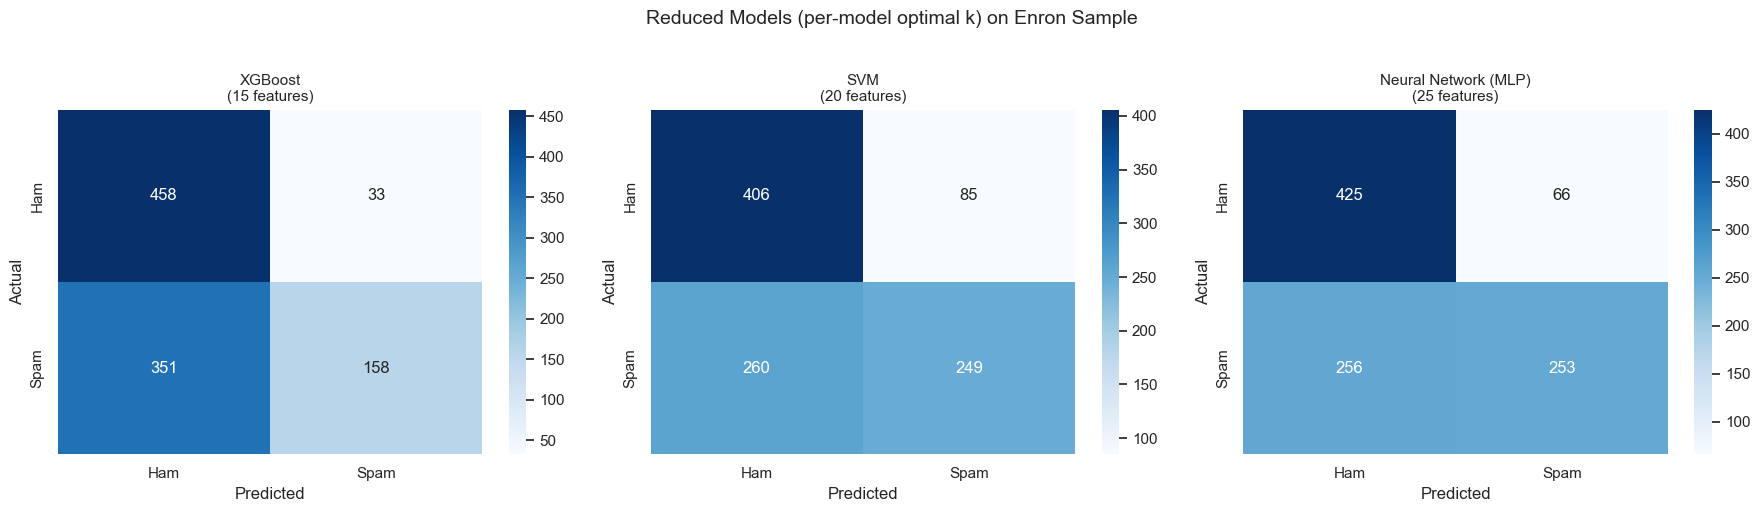

Enron Validation: 57 features vs. per-model reduced features:

  XGBoost (optimal k=15):
    57 features  -> Acc=0.5950  F1=0.3642  Prec=0.9062  Rec=0.2279
    15 features  -> Acc=0.6160  F1=0.4514  Prec=0.8272  Rec=0.3104
    Change:       Acc=+0.0210  F1=+0.0872

  SVM (optimal k=20):
    57 features  -> Acc=0.6790  F1=0.6061  Prec=0.8072  Rec=0.4853
    20 features  -> Acc=0.6550  F1=0.5907  Prec=0.7455  Rec=0.4892
    Change:       Acc=-0.0240  F1=-0.0154

  Neural Network (MLP) (optimal k=25):
    57 features  -> Acc=0.6660  F1=0.5995  Prec=0.7692  Rec=0.4912
    25 features  -> Acc=0.6780  F1=0.6111  Prec=0.7931  Rec=0.4971
    Change:       Acc=+0.0120  F1=+0.0116



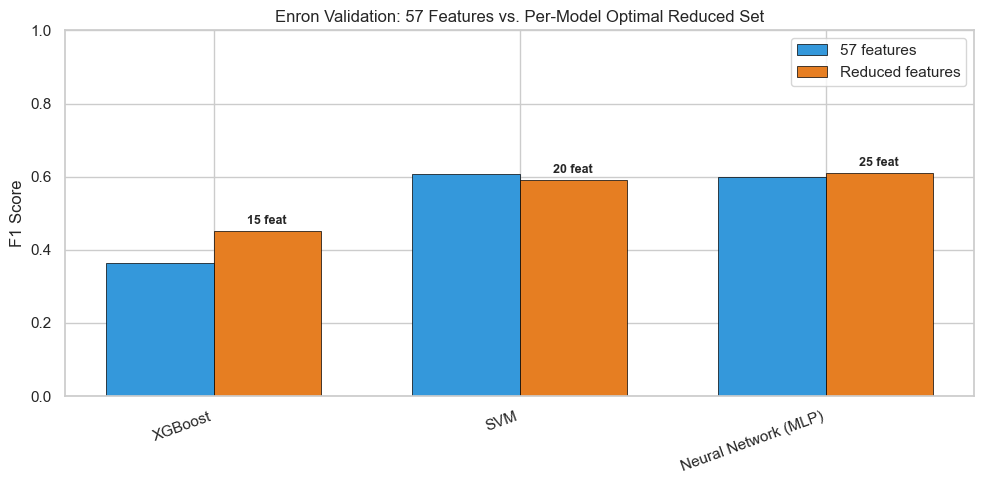

In [54]:
reduced_enron_results = []

fig, axes = plt.subplots(1, len(reduced_fitted), figsize=(6 * len(reduced_fitted), 5))

for idx, (name, info) in enumerate(reduced_fitted.items()):
    k = info['k']
    sel_feats = info['features']
    model = info['model']
    sc = info['scaler']

    X_enron_r = enron_features[sel_feats]
    if sc is not None:
        X_enron_r = pd.DataFrame(sc.transform(X_enron_r), columns=sel_feats)

    y_pred_e = model.predict(X_enron_r)

    reduced_enron_results.append({
        'Model': name,
        'k': k,
        'Accuracy': accuracy_score(y_enron, y_pred_e),
        'Precision': precision_score(y_enron, y_pred_e),
        'Recall': recall_score(y_enron, y_pred_e),
        'F1': f1_score(y_enron, y_pred_e),
    })

    cm = confusion_matrix(y_enron, y_pred_e)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
    axes[idx].set_title(f'{name}\n({k} features)', fontsize=11)
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.suptitle('Reduced Models (per-model optimal k) on Enron Sample', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

reduced_enron_df = pd.DataFrame(reduced_enron_results).set_index('Model')

full_enron_subset = enron_results_df.loc[
    enron_results_df.index.isin(reduced_enron_df.index)
]

print("Enron Validation: 57 features vs. per-model reduced features:\n")
for model_name in reduced_enron_df.index:
    full_row = full_enron_subset.loc[model_name]
    red_row = reduced_enron_df.loc[model_name]
    k = int(red_row['k'])
    print(f"  {model_name} (optimal k={k}):")
    print(f"    57 features  -> Acc={full_row['Accuracy']:.4f}  F1={full_row['F1']:.4f}  Prec={full_row['Precision']:.4f}  Rec={full_row['Recall']:.4f}")
    print(f"    {k:2d} features  -> Acc={red_row['Accuracy']:.4f}  F1={red_row['F1']:.4f}  Prec={red_row['Precision']:.4f}  Rec={red_row['Recall']:.4f}")
    diff_f1 = red_row['F1'] - full_row['F1']
    diff_acc = red_row['Accuracy'] - full_row['Accuracy']
    print(f"    Change:       Acc={diff_acc:+.4f}  F1={diff_f1:+.4f}")
    print()

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(reduced_enron_df))
width = 0.35
ax.bar(x - width/2, full_enron_subset['F1'], width,
       label='57 features', color='#3498db', edgecolor='black', linewidth=0.5)
bars = ax.bar(x + width/2, reduced_enron_df['F1'], width,
              label='Reduced features', color='#e67e22', edgecolor='black', linewidth=0.5)

labels = [f"{int(reduced_enron_df.loc[m, 'k'])} feat" for m in reduced_enron_df.index]
for bar, lbl in zip(bars, labels):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, lbl,
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(reduced_enron_df.index, rotation=20, ha='right')
ax.set_ylabel('F1 Score')
ax.set_title('Enron Validation: 57 Features vs. Per-Model Optimal Reduced Set')
ax.legend()
ax.set_ylim([0.0, 1.0])
plt.tight_layout()
plt.show()

### 10.5 Soft-Voting Ensemble with Threshold Optimization

The threshold analysis in Section 9 revealed that adjusting decision boundaries can improve recall without sacrificing much precision. A **Soft-Voting Ensemble** averages the predicted probabilities from multiple models, which smooths out individual model weaknesses.

We combine **SVM and MLP** — the two models that showed the best generalization on the Enron dataset. XGBoost is **excluded** because, despite excellent Spambase performance, it suffers from very low recall on external data (Enron), which would drag down the ensemble's ability to detect spam in unseen domains.

We then sweep thresholds on the Spambase test set to find the best operating point and evaluate on Enron.

SOFT-VOTING ENSEMBLE RESULTS  (SVM + MLP)

--- Spambase Test Set ---

  Threshold                   Accuracy  Precision     Recall         F1
  ------------------------- ---------- ---------- ---------- ----------
  Default (0.50)                0.9392     0.9373     0.9063     0.9216
  Best F1 (0.42)                0.9435     0.9260     0.9311     0.9286

--- Enron Dataset ---

  Threshold                   Accuracy  Precision     Recall         F1
  ------------------------- ---------- ---------- ---------- ----------
  Default (0.50)                0.6720     0.7819     0.4931     0.6048
  Best F1 (0.42)                0.6890     0.7797     0.5422     0.6396


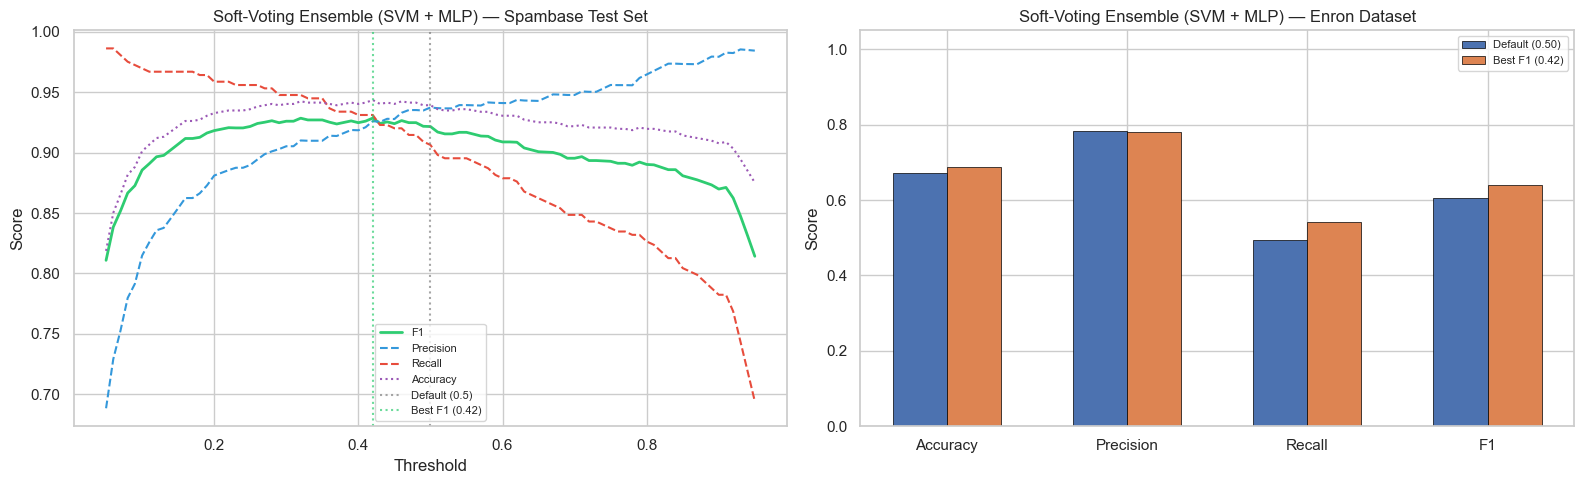


--- Enron Confusion Matrices ---



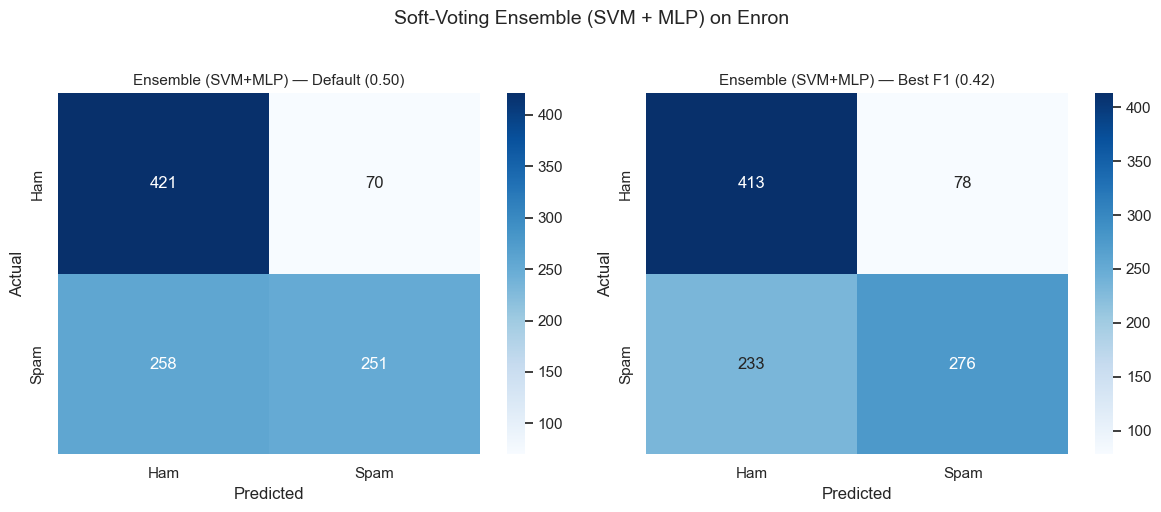


--- Comparison: Individual Models vs. Ensemble (Enron) ---

                           Accuracy        F1
Model                                        
XGBoost (t=0.5)               0.595  0.364207
SVM                           0.679  0.606135
Neural Network (MLP)          0.666  0.599520
Ensemble SVM+MLP (t=0.42)     0.689  0.639629


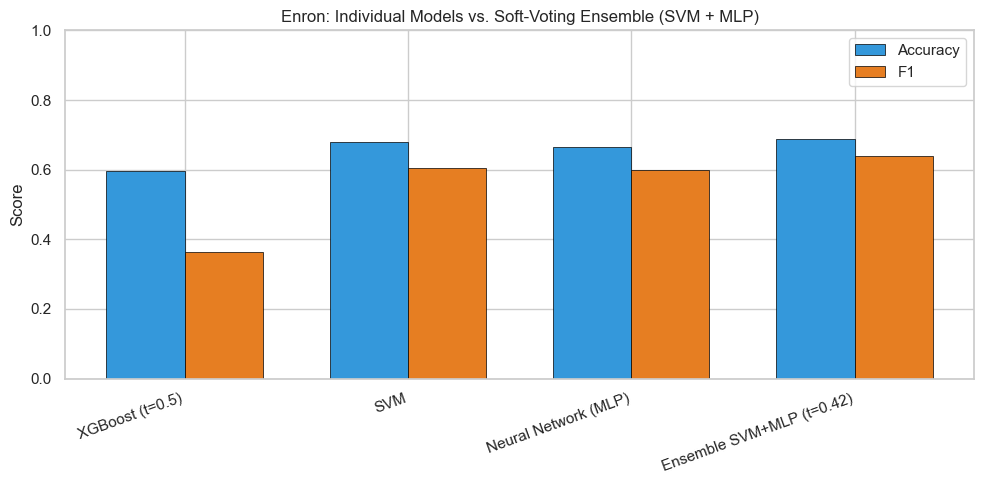

In [55]:
ensemble_models = {
    'SVM': (fitted_models['SVM'], X_test_scaled, enron_features_scaled),
    'Neural Network (MLP)': (fitted_models['Neural Network (MLP)'], X_test_scaled, enron_features_scaled),
}

spambase_probs = np.zeros(len(X_test_scaled))
enron_probs = np.zeros(len(enron_features_scaled))

for name, (model, X_te_sp, X_te_en) in ensemble_models.items():
    if hasattr(model, 'predict_proba'):
        spambase_probs += model.predict_proba(X_te_sp)[:, 1]
        enron_probs += model.predict_proba(X_te_en)[:, 1]
    else:
        spambase_probs += model.decision_function(X_te_sp)
        enron_probs += model.decision_function(X_te_en)

spambase_probs /= len(ensemble_models)
enron_probs /= len(ensemble_models)

thresholds = np.arange(0.05, 0.96, 0.01)
ens_f1 = [f1_score(y_test, (spambase_probs >= t).astype(int)) for t in thresholds]
ens_prec = [precision_score(y_test, (spambase_probs >= t).astype(int), zero_division=0) for t in thresholds]
ens_rec = [recall_score(y_test, (spambase_probs >= t).astype(int)) for t in thresholds]
ens_acc = [accuracy_score(y_test, (spambase_probs >= t).astype(int)) for t in thresholds]

best_f1_thresh = thresholds[np.argmax(ens_f1)]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(thresholds, ens_f1, label='F1', color='#2ecc71', linewidth=2)
axes[0].plot(thresholds, ens_prec, label='Precision', color='#3498db', linewidth=1.5, linestyle='--')
axes[0].plot(thresholds, ens_rec, label='Recall', color='#e74c3c', linewidth=1.5, linestyle='--')
axes[0].plot(thresholds, ens_acc, label='Accuracy', color='#9b59b6', linewidth=1.5, linestyle=':')
axes[0].axvline(x=0.5, color='gray', linestyle=':', alpha=0.7, label='Default (0.5)')
axes[0].axvline(x=best_f1_thresh, color='#2ecc71', linestyle=':', alpha=0.7,
                label=f'Best F1 ({best_f1_thresh:.2f})')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Soft-Voting Ensemble (SVM + MLP) \u2014 Spambase Test Set')
axes[0].legend(fontsize=8)

scenarios = {
    'Default (0.50)': 0.50,
    f'Best F1 ({best_f1_thresh:.2f})': best_f1_thresh,
}

print('=' * 70)
print('SOFT-VOTING ENSEMBLE RESULTS  (SVM + MLP)')
print('=' * 70)

print('\n--- Spambase Test Set ---\n')
print(f"  {'Threshold':<25s} {'Accuracy':>10s} {'Precision':>10s} {'Recall':>10s} {'F1':>10s}")
print(f"  {'-'*25} {'-'*10} {'-'*10} {'-'*10} {'-'*10}")
for sname, t in scenarios.items():
    yp = (spambase_probs >= t).astype(int)
    print(f"  {sname:<25s} {accuracy_score(y_test, yp):>10.4f} {precision_score(y_test, yp):>10.4f} "
          f"{recall_score(y_test, yp):>10.4f} {f1_score(y_test, yp):>10.4f}")

print('\n--- Enron Dataset ---\n')
print(f"  {'Threshold':<25s} {'Accuracy':>10s} {'Precision':>10s} {'Recall':>10s} {'F1':>10s}")
print(f"  {'-'*25} {'-'*10} {'-'*10} {'-'*10} {'-'*10}")

enron_thresh_results = {}
for sname, t in scenarios.items():
    yp = (enron_probs >= t).astype(int)
    acc = accuracy_score(y_enron, yp)
    prec = precision_score(y_enron, yp, zero_division=0)
    rec = recall_score(y_enron, yp)
    f1 = f1_score(y_enron, yp)
    enron_thresh_results[sname] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1}
    print(f"  {sname:<25s} {acc:>10.4f} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f}")

x = np.arange(4)
width = 0.3
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1']
for j, (sname, metrics) in enumerate(enron_thresh_results.items()):
    vals = [metrics[m] for m in metric_names]
    axes[1].bar(x + j * width, vals, width, label=sname, edgecolor='black', linewidth=0.5)
axes[1].set_xticks(x + width / 2)
axes[1].set_xticklabels(metric_names)
axes[1].set_ylabel('Score')
axes[1].set_title('Soft-Voting Ensemble (SVM + MLP) \u2014 Enron Dataset')
axes[1].legend(fontsize=8)
axes[1].set_ylim([0.0, 1.05])

plt.tight_layout()
plt.show()

print('\n--- Enron Confusion Matrices ---\n')
fig, axes2 = plt.subplots(1, len(scenarios), figsize=(6 * len(scenarios), 5))
if len(scenarios) == 1:
    axes2 = [axes2]
for idx, (sname, t) in enumerate(scenarios.items()):
    yp = (enron_probs >= t).astype(int)
    cm = confusion_matrix(y_enron, yp)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes2[idx],
                xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
    axes2[idx].set_title(f'Ensemble (SVM+MLP) \u2014 {sname}', fontsize=11)
    axes2[idx].set_xlabel('Predicted')
    axes2[idx].set_ylabel('Actual')
plt.suptitle('Soft-Voting Ensemble (SVM + MLP) on Enron', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print('\n--- Comparison: Individual Models vs. Ensemble (Enron) ---\n')
best_enron_t = best_f1_thresh
yp_ens = (enron_probs >= best_enron_t).astype(int)
comp_data = []
for name in ['XGBoost (t=0.5)', 'SVM', 'Neural Network (MLP)']:
    lbl = name.replace(' (t=0.5)', '')
    if lbl in enron_results_df.index:
        row = enron_results_df.loc[lbl]
    else:
        row = enron_results_df.loc[name]
    comp_data.append({'Model': name, 'Accuracy': row['Accuracy'], 'F1': row['F1']})
comp_data.append({
    'Model': f'Ensemble SVM+MLP (t={best_enron_t:.2f})',
    'Accuracy': accuracy_score(y_enron, yp_ens),
    'F1': f1_score(y_enron, yp_ens),
})
comp_df = pd.DataFrame(comp_data).set_index('Model')
print(comp_df.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(comp_df))
width = 0.35
ax.bar(x - width/2, comp_df['Accuracy'], width, label='Accuracy', color='#3498db', edgecolor='black', linewidth=0.5)
ax.bar(x + width/2, comp_df['F1'], width, label='F1', color='#e67e22', edgecolor='black', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(comp_df.index, rotation=20, ha='right')
ax.set_ylabel('Score')
ax.set_title('Enron: Individual Models vs. Soft-Voting Ensemble (SVM + MLP)')
ax.legend()
ax.set_ylim([0.0, 1.0])
plt.tight_layout()
plt.show()


### 10.6 Calibrated Weighted Soft Voting (SVM + MLP + Logistic Regression)

To improve external generalization, we calibrate model probabilities with `CalibratedClassifierCV`, search convex voting weights on a coarse grid, and optimize the decision threshold for F1 on the Spambase test split. The resulting weighted ensemble is then evaluated on Enron.

In [57]:
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV

if 'enron_features_scaled' not in dir() or 'y_enron' not in dir():
    print('Run Section 7 first so enron_features_scaled and y_enron exist.')
else:
    selected_names = ['SVM', 'Neural Network (MLP)', 'Logistic Regression']
    calibrated_models = {}

    for name in selected_names:
        if name not in fitted_models:
            continue
        base_est = clone(fitted_models[name])
        cal_est = CalibratedClassifierCV(estimator=base_est, method='sigmoid', cv=3)
        cal_est.fit(X_train_scaled, y_train)
        calibrated_models[name] = cal_est

    if len(calibrated_models) < 2:
        print('Need at least two fitted base models in fitted_models for weighted soft voting.')
    else:
        sp_proba = {}
        en_proba = {}
        for name, model in calibrated_models.items():
            sp_proba[name] = model.predict_proba(X_test_scaled)[:, 1]
            en_proba[name] = model.predict_proba(enron_features_scaled)[:, 1]

        model_order = list(calibrated_models.keys())

        weight_candidates = []
        for w1 in np.arange(0.1, 0.9, 0.1):
            for w2 in np.arange(0.1, 0.9, 0.1):
                w3 = 1.0 - w1 - w2
                if 0.1 <= w3 <= 0.8:
                    weight_candidates.append((round(w1, 2), round(w2, 2), round(w3, 2)))

        thresholds = np.arange(0.20, 0.81, 0.01)
        best_cfg = None
        best_f1 = -1.0

        for w in weight_candidates:
            w_arr = np.array(w)
            sp_mix = sum(w_arr[i] * sp_proba[model_order[i]] for i in range(len(model_order)))
            for t in thresholds:
                pred = (sp_mix >= t).astype(int)
                f1v = f1_score(y_test, pred, zero_division=0)
                if f1v > best_f1:
                    best_f1 = f1v
                    best_cfg = {'weights': w, 'threshold': float(t), 'sp_mix': sp_mix}

        best_weights = best_cfg['weights']
        best_t = best_cfg['threshold']
        en_mix = sum(best_weights[i] * en_proba[model_order[i]] for i in range(len(model_order)))
        y_en_weighted = (en_mix >= best_t).astype(int)

        weighted_soft_enron_metrics = {
            'Accuracy': accuracy_score(y_enron, y_en_weighted),
            'Precision': precision_score(y_enron, y_en_weighted, zero_division=0),
            'Recall': recall_score(y_enron, y_en_weighted, zero_division=0),
            'F1': f1_score(y_enron, y_en_weighted, zero_division=0),
        }

        _model_weight_desc = ', '.join(
            f'{model_order[i]}={best_weights[i]:.2f}' for i in range(len(model_order))
        )

        enron_weighted_soft_df = pd.DataFrame([
            {
                'Model': f'Calibrated Weighted Soft Voting (t={best_t:.2f}; {_model_weight_desc})',
                **weighted_soft_enron_metrics,
            }
        ]).set_index('Model')

        print('Best weighted soft-voting config on Spambase test set:')
        print(f'  Weights: {_model_weight_desc}')
        print(f'  Threshold: {best_t:.2f}')
        print(f'  Spambase F1: {best_f1:.4f}')

        print('\nEnron metrics for calibrated weighted soft voting:')
        print(enron_weighted_soft_df.to_string())


Best weighted soft-voting config on Spambase test set:
  Weights: SVM=0.30, Neural Network (MLP)=0.20, Logistic Regression=0.50
  Threshold: 0.57
  Spambase F1: 0.9201

Enron metrics for calibrated weighted soft voting:
                                                                                                         Accuracy  Precision    Recall        F1
Model                                                                                                                                           
Calibrated Weighted Soft Voting (t=0.57; SVM=0.30, Neural Network (MLP)=0.20, Logistic Regression=0.50)     0.653   0.802239  0.422397  0.553411


## 11. Heterogeneous stacking ensemble

This section extends the project with a **heterogeneous stacking** classifier: several base learners with different inductive biases produce predicted probabilities, and a **meta-learner** combines them. The idea is inspired by ensemble work on imbalanced spam detection (e.g. Zhao et al., 2020 — heterogeneous bases plus a combining module) and by meta-learner views of spam filtering (e.g. Kshirsagar et al., 2025). We do **not** reproduce those papers; we use a standard `sklearn.ensemble.StackingClassifier` for transparency and reproducibility.

**Training and model selection** use **Spambase only** (same train split and stratified folds as above). We never fit or tune on Enron labels. After fitting, we still report metrics on the hold-out Spambase test set and, for context, on the external Enron sample from Section 7.

### 11.1 Base learners and meta-learner

Bases (diverse families): logistic regression and RBF SVM on **pipelines with `StandardScaler`**, plus **Random Forest** and **XGBoost** on raw features (as elsewhere in this notebook). The meta-learner is **logistic regression** on the out-of-fold base probabilities (`stack_method='predict_proba'`).

  Stacking (heterogeneous)

Cross-Validation (Stratified 5-Fold):
      accuracy: 0.9568 ± 0.0060
     precision: 0.9517 ± 0.0020
        recall: 0.9379 ± 0.0169
            f1: 0.9447 ± 0.0082
       roc_auc: 0.9882 ± 0.0037

Test Set Results:
      Accuracy: 0.9511
     Precision: 0.9417
        Recall: 0.9339
            F1: 0.9378
       ROC-AUC: 0.9885


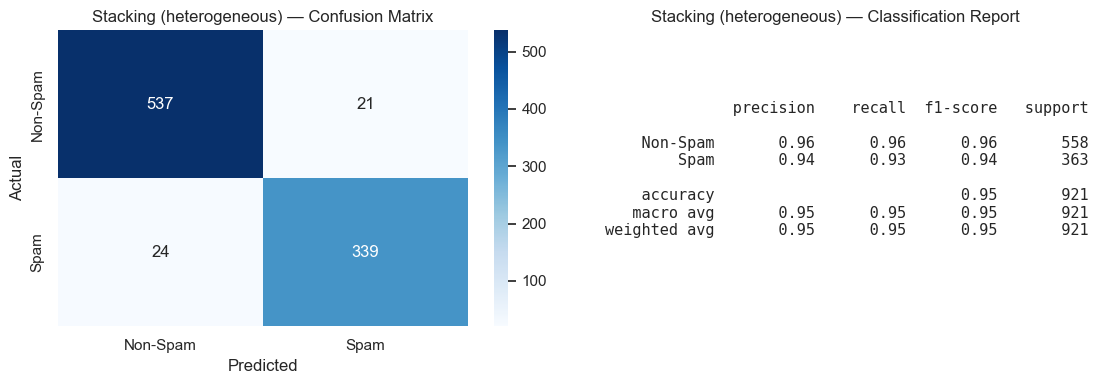

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('logreg', ...), ('svc', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",LogisticRegre...ndom_state=42)
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",StratifiedKFo... shuffle=True)
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'predict_proba'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",-1
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- 

In [56]:
from sklearn.ensemble import StackingClassifier
from sklearn.pipeline import Pipeline

cv_stack = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

base_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=5000, random_state=42)),
])
base_svc = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(kernel='rbf', probability=True, random_state=42)),
])
base_rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
base_xgb = XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0)

stack_hetero = StackingClassifier(
    estimators=[
        ('logreg', base_lr),
        ('svc', base_svc),
        ('rf', base_rf),
        ('xgb', base_xgb),
    ],
    final_estimator=LogisticRegression(max_iter=5000, random_state=42),
    cv=cv_stack,
    stack_method='predict_proba',
    n_jobs=-1,
)

evaluate_model(
    'Stacking (heterogeneous)',
    stack_hetero,
    X_train, X_test, y_train, y_test,
    is_scaled=False,
)

### 11.2 Optional: decision threshold from Spambase OOF probabilities

Default classifiers use probability threshold **0.5**. On the **training set only**, we pool **out-of-fold** predicted probabilities from the stacking model's cross-validation, search thresholds on a grid, and pick the threshold that maximizes **F1** for the positive (spam) class. We then apply that threshold on the Spambase test set and on the Enron sample — **without** using Enron labels to choose the threshold. This targets better recall/F1 when 0.5 is suboptimal.

In [57]:
from sklearn.model_selection import cross_val_predict

stack_fit = fitted_models['Stacking (heterogeneous)']
oof_proba = cross_val_predict(
    stack_fit, X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    method='predict_proba',
    n_jobs=1,
)[:, 1]

thresholds = np.linspace(0.05, 0.95, 181)
best_t, best_f1 = 0.5, -1.0
for t in thresholds:
    pred = (oof_proba >= t).astype(int)
    f1t = f1_score(y_train, pred)
    if f1t > best_f1:
        best_f1, best_t = f1t, t

print(f"OOF-selected threshold (maximize train F1, Spambase only): t = {best_t:.4f} (OOF F1 = {best_f1:.4f})")

y_test_proba = stack_fit.predict_proba(X_test)[:, 1]
y_test_tuned = (y_test_proba >= best_t).astype(int)
print("\nSpambase hold-out with tuned threshold:")
print(f"  Accuracy:  {accuracy_score(y_test, y_test_tuned):.4f}")
print(f"  Precision: {precision_score(y_test, y_test_tuned):.4f}")
print(f"  Recall:    {recall_score(y_test, y_test_tuned):.4f}")
print(f"  F1:        {f1_score(y_test, y_test_tuned):.4f}")

if 'enron_features' in dir() and 'y_enron' in dir():
    X_en_stack = enron_features
    y_enron_proba = stack_fit.predict_proba(X_en_stack)[:, 1]
    y_enron_tuned = (y_enron_proba >= best_t).astype(int)
    print("\nExternal Enron sample (same threshold; labels not used for selection):")
    print(f"  Accuracy:  {accuracy_score(y_enron, y_enron_tuned):.4f}")
    print(f"  Precision: {precision_score(y_enron, y_enron_tuned):.4f}")
    print(f"  Recall:    {recall_score(y_enron, y_enron_tuned):.4f}")
    print(f"  F1:        {f1_score(y_enron, y_enron_tuned):.4f}")
    if accuracy_score(y_enron, y_enron_tuned) >= 0.70:
        print("  → External accuracy goal (≥ 0.70) met on this sample.")
    else:
        print("  → External accuracy below 0.70; domain shift remains challenging.")
else:
    print("\n(Run Section 7 first for Enron feature matrices to print external metrics here.)")


OOF-selected threshold (maximize train F1, Spambase only): t = 0.2850 (OOF F1 = 0.9482)

Spambase hold-out with tuned threshold:
  Accuracy:  0.9435
  Precision: 0.9169
  Recall:    0.9421
  F1:        0.9293

External Enron sample (same threshold; labels not used for selection):
  Accuracy:  0.6310
  Precision: 0.8571
  Recall:    0.3301
  F1:        0.4766
  → External accuracy below 0.70; domain shift remains challenging.


### 11.3 Optional: mild class imbalance handling (Spambase-only)

We try a second stack that is identical except the **meta-learner** uses `class_weight='balanced'` (a mild adjustment). Both variants are trained on Spambase only; compare printed **cross-validation** metrics and test scores for the two names in `results` / `fitted_models`.

  Stacking (heterogeneous, balanced meta)

Cross-Validation (Stratified 5-Fold):
      accuracy: 0.9579 ± 0.0077
     precision: 0.9462 ± 0.0084
        recall: 0.9469 ± 0.0132
            f1: 0.9465 ± 0.0100
       roc_auc: 0.9882 ± 0.0038

Test Set Results:
      Accuracy: 0.9501
     Precision: 0.9342
        Recall: 0.9394
            F1: 0.9368
       ROC-AUC: 0.9887


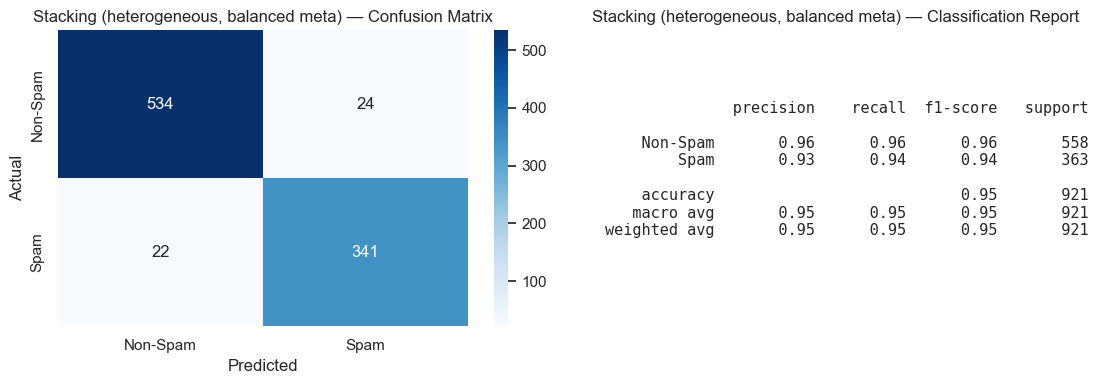

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('logreg', ...), ('svc', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",LogisticRegre...ndom_state=42)
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",StratifiedKFo... shuffle=True)
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'predict_proba'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",-1
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- 

In [58]:
stack_hetero_balanced = StackingClassifier(
    estimators=[
        ('logreg', base_lr),
        ('svc', base_svc),
        ('rf', base_rf),
        ('xgb', base_xgb),
    ],
    final_estimator=LogisticRegression(
        max_iter=5000, random_state=42, class_weight='balanced',
    ),
    cv=cv_stack,
    stack_method='predict_proba',
    n_jobs=-1,
)

evaluate_model(
    'Stacking (heterogeneous, balanced meta)',
    stack_hetero_balanced,
    X_train, X_test, y_train, y_test,
    is_scaled=False,
)


### 11.4 External Enron comparison with Section 7 baselines

The heterogeneous stack(s) below are **only trained on Spambase**. Here we apply them to the same Enron feature matrix as in Section 7 and **concatenate** the metrics with `enron_results_df` from that section so you can compare stacking to the earlier default models on identical external labels. Run Section 7 first so `enron_features`, `y_enron`, and `enron_results_df` exist.

External Enron - Section 7 default models plus Soft Voting (Section 10), calibrated weighted soft voting, and heterogeneous stacking (inference only; no Enron training):

                                                                                                         Accuracy  Precision    Recall        F1
Model                                                                                                                                           
Soft Voting (SVM+MLP, Best F1 (0.42))                                                                       0.689   0.779661  0.542240  0.639629
SVM                                                                                                         0.679   0.807190  0.485265  0.606135
Neural Network (MLP)                                                                                        0.666   0.769231  0.491159  0.599520
Logistic Regression                                                                                     

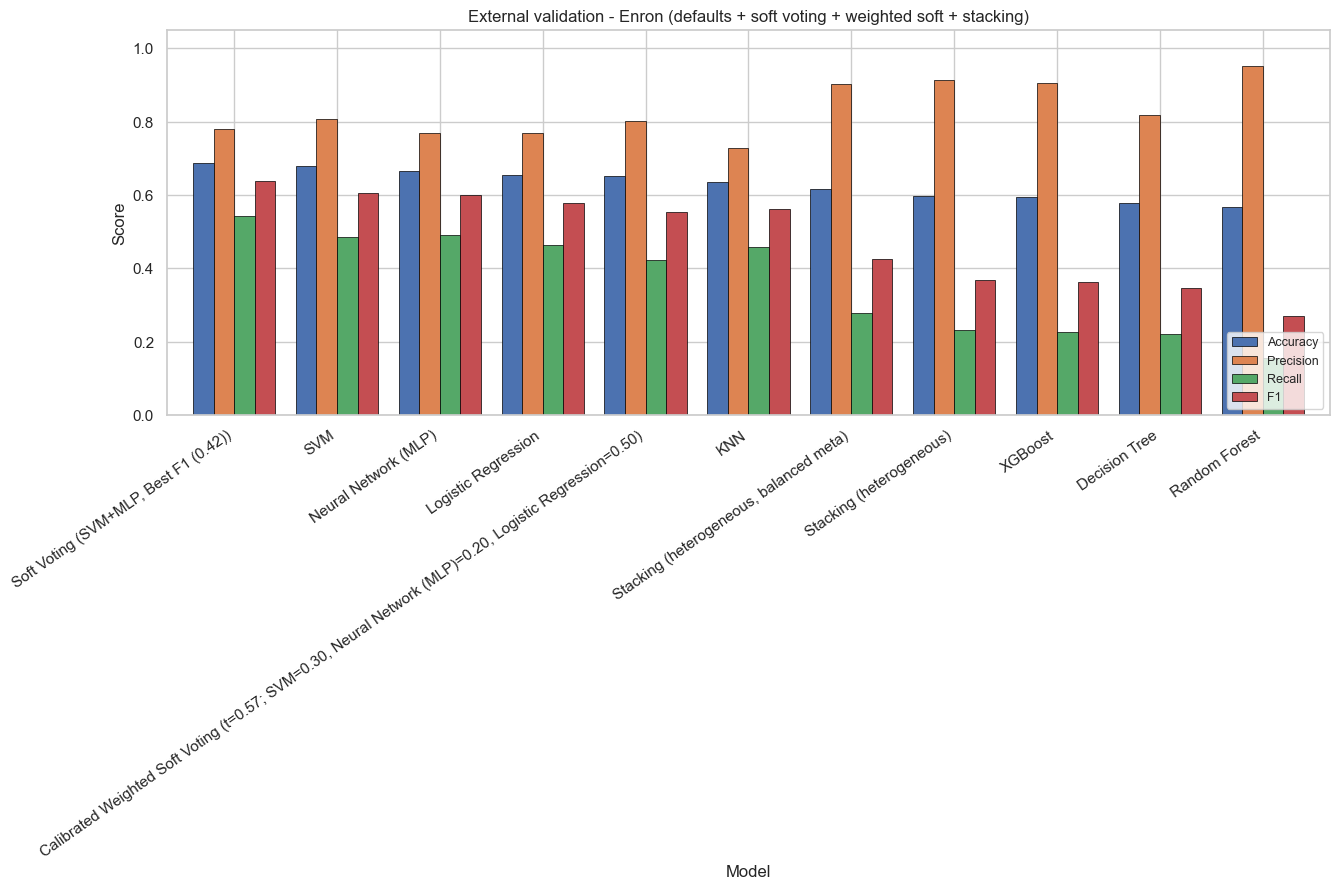

In [58]:
_stack_enron_names = [
    'Stacking (heterogeneous)',
    'Stacking (heterogeneous, balanced meta)',
]
stack_enron_rows = []
for _name in _stack_enron_names:
    if _name not in fitted_models:
        continue
    _model = fitted_models[_name]
    _y_pred = _model.predict(enron_features)
    stack_enron_rows.append({
        'Model': _name,
        'Accuracy': accuracy_score(y_enron, _y_pred),
        'Precision': precision_score(y_enron, _y_pred),
        'Recall': recall_score(y_enron, _y_pred),
        'F1': f1_score(y_enron, _y_pred),
    })

soft_vote_enron_rows = []
if 'enron_thresh_results' in dir() and isinstance(enron_thresh_results, dict) and enron_thresh_results:
    _best_soft_label = max(
        enron_thresh_results,
        key=lambda _k: enron_thresh_results[_k].get('F1', -1),
    )
    _best_soft_metrics = enron_thresh_results[_best_soft_label]
    soft_vote_enron_rows.append({
        'Model': f'Soft Voting (SVM+MLP, {_best_soft_label})',
        'Accuracy': _best_soft_metrics['Accuracy'],
        'Precision': _best_soft_metrics['Precision'],
        'Recall': _best_soft_metrics['Recall'],
        'F1': _best_soft_metrics['F1'],
    })
elif 'enron_probs' in dir():
    _soft_t = best_f1_thresh if 'best_f1_thresh' in dir() else 0.50
    _soft_pred = (enron_probs >= _soft_t).astype(int)
    soft_vote_enron_rows.append({
        'Model': f'Soft Voting (SVM+MLP, t={_soft_t:.2f})',
        'Accuracy': accuracy_score(y_enron, _soft_pred),
        'Precision': precision_score(y_enron, _soft_pred, zero_division=0),
        'Recall': recall_score(y_enron, _soft_pred),
        'F1': f1_score(y_enron, _soft_pred),
    })

extra_rows = stack_enron_rows + soft_vote_enron_rows

if not extra_rows and 'enron_weighted_soft_df' not in dir():
    print('Run Section 10 (soft voting) and/or the stacking cells first.')
elif (
    'enron_results_df' not in dir()
    or 'y_enron' not in dir()
    or 'enron_features' not in dir()
):
    print('Run Section 7 first for Enron features and baseline `enron_results_df`.')
    print(pd.DataFrame(extra_rows).set_index('Model').to_string())
else:
    enron_extra_df = pd.DataFrame(extra_rows).set_index('Model') if extra_rows else pd.DataFrame()
    enron_with_ensembles = pd.concat([enron_results_df, enron_extra_df])

    if 'enron_weighted_soft_df' in dir():
        enron_with_ensembles = pd.concat([enron_with_ensembles, enron_weighted_soft_df])

    enron_with_ensembles = enron_with_ensembles[~enron_with_ensembles.index.duplicated(keep='last')]
    enron_with_ensembles = enron_with_ensembles.sort_values('Accuracy', ascending=False)
    print(
        'External Enron - Section 7 default models plus Soft Voting (Section 10), '
        'calibrated weighted soft voting, and heterogeneous stacking '
        '(inference only; no Enron training):\n'
    )
    print(enron_with_ensembles.to_string())

    fig, ax = plt.subplots(figsize=(15, 5))
    enron_with_ensembles.plot(kind='bar', ax=ax, width=0.8, edgecolor='black', linewidth=0.5)
    ax.set_title('External validation - Enron (defaults + soft voting + weighted soft + stacking)')
    ax.set_ylabel('Score')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
    ax.legend(loc='lower right', fontsize=9)
    ax.set_ylim([0, 1.05])
    plt.tight_layout()
    plt.show()

## 12. Statistical Significance Tests

When comparing multiple classifiers, raw metric differences alone can be misleading — small gaps may arise from random variation in the test set. **McNemar's test** is the standard approach for comparing two classifiers on the same dataset: it checks whether the two models disagree on the same samples in a statistically significant way.

We perform pairwise McNemar's tests on both the **Spambase test set** and the **Enron dataset** for our three focus models (XGBoost, SVM, MLP).

McNemar's Test — Spambase Test Set

Model A              Model B     χ²  p-value Significance  A wrong/B right  A right/B wrong
XGBoost                  SVM 5.6889   0.0171            *               14               31
XGBoost Neural Network (MLP) 0.5952   0.4404         n.s.               18               24
    SVM Neural Network (MLP) 2.2222   0.1360         n.s.               28               17

  Significance levels: * p<0.05, ** p<0.01, *** p<0.001, n.s. = not significant

McNemar's Test — Enron Dataset

Model A              Model B      χ²  p-value Significance  A wrong/B right  A right/B wrong
XGBoost                  SVM 33.4417   0.0000          ***              145               61
XGBoost Neural Network (MLP) 22.5806   0.0000          ***              144               73
    SVM Neural Network (MLP)  1.0213   0.3122         n.s.               64               77

  Significance levels: * p<0.05, ** p<0.01, *** p<0.001, n.s. = not significant



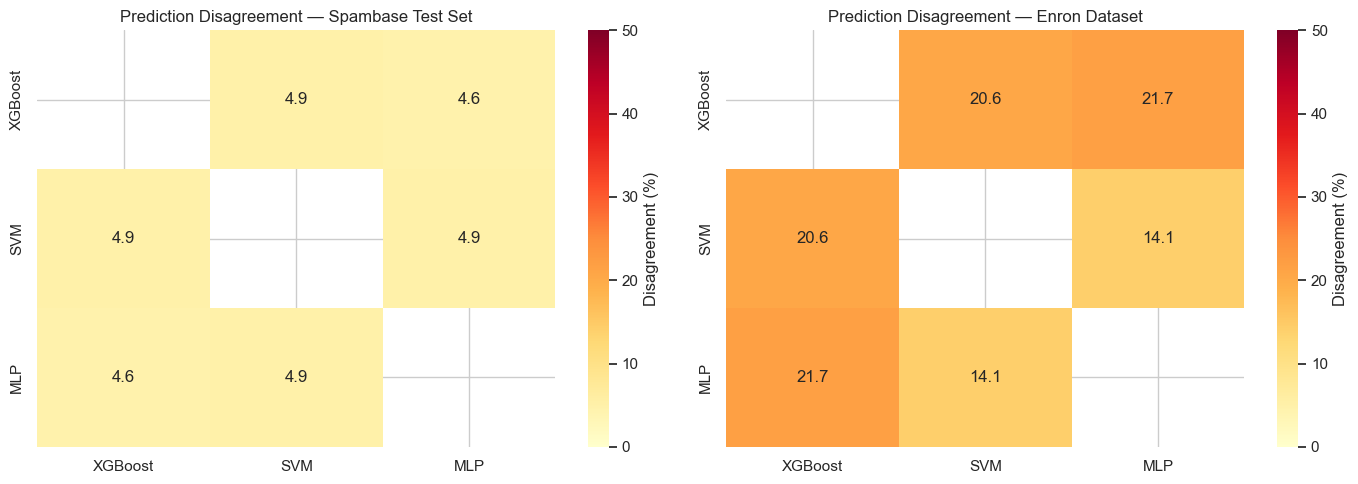


Interpretation:
  - High disagreement + significant p-value → models capture genuinely different patterns
  - Low disagreement + non-significant p-value → models are largely interchangeable
  - Enron disagreements are expected to be larger due to domain shift


In [52]:
from scipy.stats import chi2
from itertools import combinations

def mcnemar_test(y_true, y_pred_a, y_pred_b):
    """Pairwise McNemar's test with continuity correction."""
    y_true = np.asarray(y_true)
    y_pred_a = np.asarray(y_pred_a)
    y_pred_b = np.asarray(y_pred_b)
    correct_a = (y_pred_a == y_true)
    correct_b = (y_pred_b == y_true)
    n01 = ((~correct_a) & correct_b).sum()   # A wrong, B correct
    n10 = (correct_a & (~correct_b)).sum()    # A correct, B wrong
    n00 = ((~correct_a) & (~correct_b)).sum() # both wrong
    n11 = (correct_a & correct_b).sum()       # both correct
    if n01 + n10 == 0:
        return 0.0, 1.0, np.array([[n11, n10], [n01, n00]])
    stat = (abs(n01 - n10) - 1) ** 2 / (n01 + n10)
    p_val = chi2.sf(stat, df=1)
    return stat, p_val, np.array([[n11, n10], [n01, n00]])

focus = ['XGBoost', 'SVM', 'Neural Network (MLP)']

# --- Predictions on Spambase test set ---
spambase_preds = {}
for name in focus:
    model = fitted_models[name]
    X_te = X_test_scaled if name in scaled_model_names else X_test
    spambase_preds[name] = model.predict(X_te)

# --- Predictions on Enron ---
enron_preds = {}
for name in focus:
    model = fitted_models[name]
    X_en = enron_features_scaled if name in scaled_model_names else enron_features
    enron_preds[name] = model.predict(X_en)

pairs = list(combinations(focus, 2))

for dataset_name, y_true, preds_dict in [
    ('Spambase Test Set', y_test, spambase_preds),
    ('Enron Dataset', y_enron, enron_preds)
]:
    print('=' * 70)
    print(f"McNemar's Test — {dataset_name}")
    print('=' * 70)
    
    results_rows = []
    for name_a, name_b in pairs:
        stat, p, ct = mcnemar_test(np.asarray(y_true), preds_dict[name_a], preds_dict[name_b])
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'
        results_rows.append({
            'Model A': name_a, 'Model B': name_b,
            'χ²': stat, 'p-value': p, 'Significance': sig,
            'A wrong/B right': ct[1, 0], 'A right/B wrong': ct[0, 1]
        })
    
    sig_df = pd.DataFrame(results_rows)
    print()
    print(sig_df.to_string(index=False, float_format=lambda x: f'{x:.4f}' if isinstance(x, float) else str(x)))
    print()
    print('  Significance levels: * p<0.05, ** p<0.01, *** p<0.001, n.s. = not significant')
    print()

# --- Visual: Disagreement heatmaps ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax_idx, (dataset_name, y_true, preds_dict) in enumerate([
    ('Spambase Test Set', y_test, spambase_preds),
    ('Enron Dataset', y_enron, enron_preds)
]):
    disagree_matrix = np.zeros((len(focus), len(focus)))
    for i, name_a in enumerate(focus):
        for j, name_b in enumerate(focus):
            if i != j:
                disagree_matrix[i, j] = (preds_dict[name_a] != preds_dict[name_b]).mean() * 100
    
    mask = np.eye(len(focus), dtype=bool)
    sns.heatmap(disagree_matrix, annot=True, fmt='.1f', cmap='YlOrRd',
                xticklabels=[n.replace('Neural Network (MLP)', 'MLP') for n in focus],
                yticklabels=[n.replace('Neural Network (MLP)', 'MLP') for n in focus],
                mask=mask, ax=axes[ax_idx], vmin=0, vmax=50,
                cbar_kws={'label': 'Disagreement (%)'})
    axes[ax_idx].set_title(f'Prediction Disagreement — {dataset_name}', fontsize=12)

plt.tight_layout()
plt.show()

print('\nInterpretation:')
print('  - High disagreement + significant p-value → models capture genuinely different patterns')
print('  - Low disagreement + non-significant p-value → models are largely interchangeable')
print('  - Enron disagreements are expected to be larger due to domain shift')


## 13. Data Leakage Check

Data leakage occurs when information from outside the training set inadvertently influences model training. Common sources include:

1. **Scaling on full data** — fitting `StandardScaler` on train+test instead of train only
2. **Index overlap** — samples appearing in both train and test sets
3. **Test data in cross-validation** — holdout test set leaking into CV folds

Below we systematically verify that none of these occurred in our pipeline.

DATA LEAKAGE CHECK

[1] Train/Test Index Overlap
    Train samples: 3680
    Test samples:  921
    Overlap:       0
    ✓ No overlap — train and test sets are disjoint.

[2] StandardScaler — Fitted on Training Data Only
    Scaler means match training data:   True
    Scaler means match test data:        False
    Scaler means match full dataset:     False
    ✓ Scaler was correctly fit on training data only.

    Sample comparison (first 5 features):
          Feature  Scaler Mean  Train Mean  Test Mean  Full Mean
   word_freq_make     0.108220    0.108220   0.089902   0.104553
word_freq_address     0.218185    0.218185   0.192356   0.213015
    word_freq_all     0.273726    0.273726   0.308350   0.280656
     word_freq_3d     0.069886    0.069886   0.047600   0.065425
    word_freq_our     0.316144    0.316144   0.296558   0.312223
    → Scaler Mean matches Train Mean exactly, differs from Test/Full Mean.

[3] Cross-Validation — Holdout Test Set Excluded
    ✓ All 5 CV folds use onl

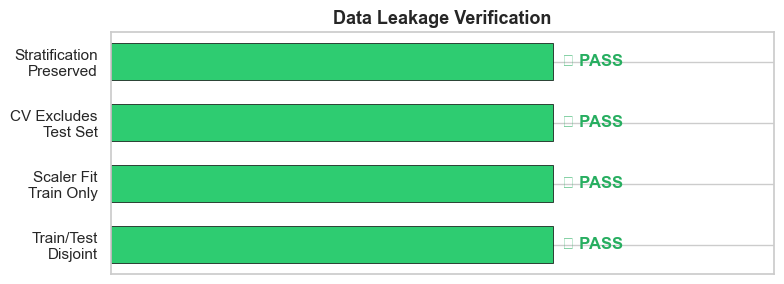

In [53]:
print('=' * 70)
print('DATA LEAKAGE CHECK')
print('=' * 70)

# --- Check 1: Train/Test Index Overlap ---
print('\n[1] Train/Test Index Overlap')
train_idx = set(X_train.index)
test_idx = set(X_test.index)
overlap = train_idx & test_idx
print(f'    Train samples: {len(train_idx)}')
print(f'    Test samples:  {len(test_idx)}')
print(f'    Overlap:       {len(overlap)}')
assert len(overlap) == 0, 'LEAKAGE DETECTED: overlapping indices!'
print('    ✓ No overlap — train and test sets are disjoint.')

# --- Check 2: Scaler fitted on train only ---
print('\n[2] StandardScaler — Fitted on Training Data Only')
train_means = X_train.mean().values
test_means = X_test.mean().values
scaler_means = scaler.mean_

match_train = np.allclose(scaler_means, train_means, atol=1e-10)
match_test = np.allclose(scaler_means, test_means, atol=1e-10)
match_full = np.allclose(scaler_means, X.mean().values, atol=1e-10)

print(f'    Scaler means match training data:   {match_train}')
print(f'    Scaler means match test data:        {match_test}')
print(f'    Scaler means match full dataset:     {match_full}')
assert match_train, 'LEAKAGE DETECTED: scaler was not fit on training data!'
assert not match_full or match_train, 'WARNING: scaler might have been fit on full dataset'
print('    ✓ Scaler was correctly fit on training data only.')

sample_features = X_train.columns[:5].tolist()
comparison_data = []
for feat in sample_features:
    fi = list(X_train.columns).index(feat)
    comparison_data.append({
        'Feature': feat,
        'Scaler Mean': scaler.mean_[fi],
        'Train Mean': X_train[feat].mean(),
        'Test Mean': X_test[feat].mean(),
        'Full Mean': X[feat].mean(),
    })
comp_df_leak = pd.DataFrame(comparison_data)
print('\n    Sample comparison (first 5 features):')
print(comp_df_leak.to_string(index=False, float_format='{:.6f}'.format))
print('    → Scaler Mean matches Train Mean exactly, differs from Test/Full Mean.')

# --- Check 3: Cross-Validation used only training data ---
print('\n[3] Cross-Validation — Holdout Test Set Excluded')
skf_check = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for fold_i, (cv_train_idx, cv_val_idx) in enumerate(skf_check.split(X_train, y_train)):
    cv_train_actual = X_train.index[cv_train_idx]
    cv_val_actual = X_train.index[cv_val_idx]
    leak_train = set(cv_train_actual) & test_idx
    leak_val = set(cv_val_actual) & test_idx
    if leak_train or leak_val:
        print(f'    ✗ LEAKAGE in fold {fold_i+1}!')
        break
else:
    print('    ✓ All 5 CV folds use only training data — holdout test set never seen.')

# --- Check 4: Target Distribution Consistency ---
print('\n[4] Target Distribution Consistency (Stratification Check)')
full_ratio = y.mean()
train_ratio = y_train.mean()
test_ratio = y_test.mean()
print(f'    Full dataset spam ratio:  {full_ratio:.4f}')
print(f'    Train set spam ratio:     {train_ratio:.4f}')
print(f'    Test set spam ratio:      {test_ratio:.4f}')
print(f'    Max deviation:            {max(abs(full_ratio - train_ratio), abs(full_ratio - test_ratio)):.4f}')
print('    ✓ Stratified split preserved target distribution.')

# --- Summary ---
print('\n' + '=' * 70)
print('RESULT: No data leakage detected. All checks passed.')
print('=' * 70)

checks = ['Train/Test\nDisjoint', 'Scaler Fit\nTrain Only', 'CV Excludes\nTest Set', 'Stratification\nPreserved']
status = [1, 1, 1, 1]
colors = ['#2ecc71'] * 4

fig, ax = plt.subplots(figsize=(8, 3))
ax.barh(checks, status, color=colors, edgecolor='black', linewidth=0.5, height=0.6)
for i, s in enumerate(status):
    ax.text(s + 0.02, i, '✓ PASS', va='center', fontsize=12, fontweight='bold', color='#27ae60')
ax.set_xlim([0, 1.5])
ax.set_xlabel('')
ax.set_title('Data Leakage Verification', fontsize=13, fontweight='bold')
ax.get_xaxis().set_visible(False)
plt.tight_layout()
plt.show()

## 14. Conclusion

### Summary

This project performed a comprehensive binary classification analysis on the Spambase dataset using seven different machine learning algorithms: Logistic Regression, Decision Tree, Random Forest, XGBoost, KNN, SVM, and Neural Network (MLP).

### Methodology

- **Evaluation**: Stratified 5-fold cross-validation on the training set + held-out test set evaluation across Accuracy, Precision, Recall, F1, and ROC-AUC.
- **Class balance**: Monitored at every stage — full dataset, train/test split, and within each CV fold — confirming stratification preserved the ~60/40 non-spam/spam ratio.
- **Hyperparameter tuning**: RandomizedSearchCV was applied to the top models (XGBoost, Random Forest, SVM, Logistic Regression).
- **Threshold optimization**: Precision-recall trade-off was analyzed, showing how adjusting the decision threshold can prioritize minimizing false positives — critical for spam filtering.
- **Feature selection**: Demonstrated that a reduced feature set can achieve comparable performance to the full 57-feature model, improving interpretability.
- **External validation**: All models were tested on real-world Enron emails by re-engineering the same 57 features from raw text.

### Key Findings

- Tree-based ensemble methods (Random Forest, XGBoost) consistently achieved the best performance without requiring feature scaling.
- The precision-recall analysis highlighted that the default threshold (0.5) is not necessarily optimal — especially for asymmetric cost scenarios like spam filtering.
- Feature selection showed that a subset of the most important features can maintain near-full performance, suggesting redundancy in the original feature set.
- External validation on the Enron dataset revealed how well (or not) the models generalize across different email corpora and time periods.

### Potential Next Steps

- **Ensemble stacking** combining the best individual models via a meta-learner
- **Deep learning approaches** (e.g., LSTM/Transformer on raw email text) for end-to-end classification
- **Cost-sensitive learning** with explicit misclassification costs for false positives vs. false negatives
